In [51]:
from read_model_runs import read_model_runs

# Ler dados completos
question_long_df, model_wide_accuracy_df, question_wide_accuracy_df, firac_order, model_order = read_model_runs('../data/processed/model-runs')

# Filtrar apenas as linhas em português
question_long_df = question_long_df[question_long_df["language"] == "portuguese"].copy()

print('shape', question_long_df.shape)
print('# unique questions', question_long_df['question_id'].nunique())
print('firac_order', firac_order)
print('model_order', model_order)

question_long_df = question_long_df[
    question_long_df["model_name"].str.contains("gemma", case=False, na=False) &
    ~question_long_df["model_name"].str.contains("gemma-3n-", case=False, na=False)
]

question_long_df = question_long_df[question_long_df["firac"].ne("F____")]
#question_long_df = question_long_df[question_long_df["firac"].ne("unstructured")]
#question_long_df = question_long_df.dropna()

question_long_df.head(1)

question_long_df[question_long_df.materia == 'FILOSOFIA'].head()


shape (65737, 30)
# unique questions 3229
firac_order ['FILA_', 'FIR__', 'FI___', 'FIL__', 'F____', '_____', 'unstructured']
model_order ['gemini-2.0-flash-lite', 'gemini-2.5-flash-lite', 'gemma-3-27b-it', 'gemma-3-12b-it', 'gemma-3n-e4b-it', 'gemma-3n-e2b-it', 'gemma-3-4b-it']


,model_name,firac,language,is_correct,pdf_filename,question_id,materia,oab_test_id,oab_question_id,chosen_option,correct_option,enunciado,prompt,finish_reason,avg_logprobs,input_token_count,output_token_count,A,B,C,D,full_response,Facts,Issue,Rule,Application,Conclusion,rule_count,fact_count,response_time_seconds
2775,gemma-3-12b-it,FILA_,portuguese,True,oab-40.pdf,oab-40.pdf-006,FILOSOFIA,XII,6,C,C,O utilitarismo é uma filosofia moderna que con...,Resolva a questão juridica abaixo considerando...,STOP,0.0,433,0,"mecanicismo, fatalismo e antifundacionalismo.","consequencialismo, transcendentalismo e fundac...","convencionalismo, consequencialismo e antifund...","convencionalismo, materialismo e fatalismo.","{\n ""F"": ""O utilitarismo é uma filosofia moder...",O utilitarismo é uma filosofia moderna que con...,Quais são as principais características da fil...,"Utilitarismo, Convencionalismo (no Utilitarism...",O utilitarismo é uma doutrina filosófica cujo ...,"A alternativa correta é a C, pois o utilitaris...",4,0,9.352558
2776,gemma-3-12b-it,FILA_,portuguese,True,oab-40.pdf,oab-40.pdf-010,FILOSOFIA,X,10,B,B,“Manter os próprios compromissos não constitui...,Resolva a questão juridica abaixo considerando...,STOP,0.0,866,0,"A coerção, tanto no direito quanto na moral, é...",A conduta moral refere-se à vontade interna do...,"O direito e a moral são idênticos, tanto na fo...",Direito e moral são absolutamente distintos. C...,"{\n ""F"":[\n ""Manter os próprios compromissos ...",['Manter os próprios compromissos constitui um...,Qual é a relação correta entre o direito e a m...,"FERRAZ JUNIOR, Tércio Sampaio. Introdução ao E...","A vontade do indivíduo, enquanto não externali...",NaN,1,4,24.658141
2777,gemma-3-12b-it,FILA_,portuguese,True,oab-40.pdf,oab-40.pdf-003,FILOSOFIA,XIII,3,B,B,"Segundo Chaïm Perelman, ao tratar da argumenta...",Resolva a questão juridica abaixo considerando...,STOP,0.0,593,0,"As cortes superiores, os organismos internacio...","As partes em litígio, os profissionais do dire...","As partes em litígio, o parlamento e as cortes...","A opinião pública, o parlamento e as cortes su...","{\n ""F"":[\n ""A questão jurídica aborda a teor...","[""A questão jurídica aborda a teoria da argume...",Quais são os três auditórios que uma decisão j...,"Chaïm Perelman, Lógica Jurídica",O raciocínio judiciário deve ser ajustado de a...,NaN,1,2,6.248541
2778,gemma-3-12b-it,FILA_,portuguese,True,oab-41.pdf,oab-41.pdf-014,FILOSOFIA,XVI,14,A,A,"Rudolf Von Ihering, em A Luta pelo Direito, af...",Resolva a questão juridica abaixo considerando...,STOP,0.0,671,0,O Direito de uma sociedade é a expressão dos c...,O Direito é o produto do espírito do povo – vo...,O Direito é parte da infraestrutura da socieda...,O Direito resulta da ação institucional do Est...,"{\n ""F"":[\n ""Rudolf Von Ihering, na obra 'A L...","[""Rudolf Von Ihering, na obra 'A Luta pelo Dir...",Qual é a interpretação e o significado da afir...,"Teoria de Rudolf von Ihering, Teoria do Espíri...",A frase de Ihering é interpretada no sentido d...,NaN,4,1,8.445340
2779,gemma-3-12b-it,FILA_,portuguese,True,oab-40.pdf,oab-40.pdf-011,FILOSOFIA,XV,11,C,C,"Na Doutrina do Direito, Kant busca um conceito...",Resolva a questão juridica abaixo considerando...,STOP,0.0,749,0,Age de forma que conserves sempre a tua liberd...,"Age de tal maneira que uses a humanidade, tant...","Age exteriormente, de modo que o livre uso de ...",Age como se a máxima de tua ação se devesse to...,"{\n ""F"":[\n ""Na Doutrina do Direito, busca-se...","['Na Doutrina do Direito, busca-se um conceito...",Qual é a formulação da lei universal do direit...,Lei da Humanidade (Imperativo Categórico de Ka...,Ao analisar as diferentes formulações apresent...,NaN,4,4,24.026016


In [52]:
question_long_df.columns

Index(['model_name', 'firac', 'language', 'is_correct', 'pdf_filename',
       'question_id', 'materia', 'oab_test_id', 'oab_question_id',
       'chosen_option', 'correct_option', 'enunciado', 'prompt',
       'finish_reason', 'avg_logprobs', 'input_token_count',
       'output_token_count', 'A', 'B', 'C', 'D', 'full_response', 'Facts',
       'Issue', 'Rule', 'Application', 'Conclusion', 'rule_count',
       'fact_count', 'response_time_seconds'],
      dtype='object')

In [53]:
question_long_df['model_name'].unique()

array(['gemma-3-12b-it', 'gemma-3-27b-it', 'gemma-3-4b-it'], dtype=object)

In [54]:
import pandas as pd

question_agg_df = pd.read_csv("../data/processed/question_statistics.csv")


question_agg_df.head()

,question_id,accuracy,input_token_count,fact_count,rule_count,avg_consistency,logic_relation_application_CONTRADICTION,logic_relation_application_ENTAILMENT,logic_relation_application_NEUTRAL,logic_relation_rule_CONTRADICTION,logic_relation_rule_ENTAILMENT,logic_relation_rule_NEUTRAL,logic_relation_conclusion_CONTRADICTION,logic_relation_conclusion_ENTAILMENT,logic_relation_conclusion_NEUTRAL,logic_relation_total_NEUTRAL,logic_relation_total_ENTAILMENT,logic_relation_total_CONTRADICTION
0,oab-1.pdf-001,0.666667,737,5,3,0.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,oab-1.pdf-002,0.866667,791,7,3,1.000000,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0
2,oab-1.pdf-003,0.533333,1096,6,4,1.000000,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0
3,oab-1.pdf-004,0.733333,587,4,1,1.000000,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0
4,oab-1.pdf-005,0.666667,703,3,2,0.000000,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0


In [55]:
counts = (
    question_long_df
        .groupby("question_id")
        .size()
        .reset_index(name="row_count")
        .sort_values("row_count", ascending=False)
)

# Total antes do filtro
total_question_ids = len(counts)

# Obtém o count máximo
max_count = counts["row_count"].max()

# Filtra apenas os question_id com o count máximo
question_ids = counts.loc[counts["row_count"] == max_count, "question_id"].tolist()

max_count, len(question_ids), total_question_ids, question_ids


(18,
 1806,
 3228,
 ['oab-99.pdf-011',
  'oab-50.pdf-042',
  'oab-47.pdf-005',
  'oab-47.pdf-006',
  'oab-47.pdf-009',
  'oab-47.pdf-010',
  'oab-47.pdf-012',
  'oab-48.pdf-015',
  'oab-48.pdf-016',
  'oab-48.pdf-017',
  'oab-48.pdf-019',
  'oab-227.pdf-093',
  'oab-227.pdf-091',
  'oab-48.pdf-020',
  'oab-48.pdf-021',
  'oab-227.pdf-087',
  'oab-227.pdf-086',
  'oab-226.pdf-082',
  'oab-48.pdf-023',
  'oab-226.pdf-079',
  'oab-226.pdf-078',
  'oab-226.pdf-076',
  'oab-226.pdf-074',
  'oab-49.pdf-024',
  'oab-225.pdf-072',
  'oab-49.pdf-025',
  'oab-225.pdf-068',
  'oab-225.pdf-067',
  'oab-49.pdf-027',
  'oab-23.pdf-224',
  'oab-23.pdf-225',
  'oab-23.pdf-226',
  'oab-231.pdf-128',
  'oab-45.pdf-056',
  'oab-45.pdf-058',
  'oab-45.pdf-059',
  'oab-232.pdf-143',
  'oab-45.pdf-060',
  'oab-232.pdf-138',
  'oab-45.pdf-063',
  'oab-232.pdf-136',
  'oab-46.pdf-001',
  'oab-46.pdf-002',
  'oab-231.pdf-130',
  'oab-46.pdf-003',
  'oab-231.pdf-124',
  'oab-23.pdf-227',
  'oab-46.pdf-068',
  '

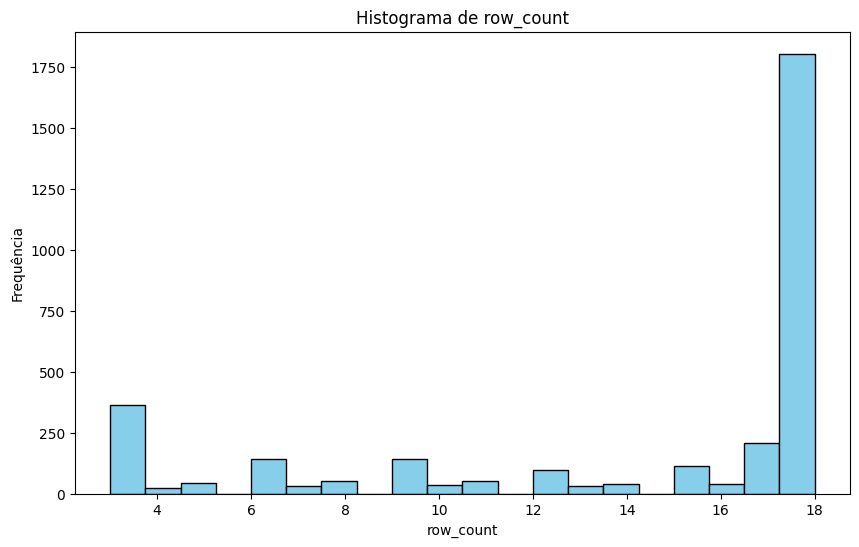

In [56]:
import matplotlib.pyplot as plt

# Gera o histograma da coluna 'row_count'
plt.figure(figsize=(10,6))
plt.hist(counts['row_count'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histograma de row_count')
plt.xlabel('row_count')
plt.ylabel('Frequência')
plt.show()



In [57]:
question_long_df = question_long_df[
    question_long_df["question_id"].isin(question_ids)
]

question_long_df.head()

,model_name,firac,language,is_correct,pdf_filename,question_id,materia,oab_test_id,oab_question_id,chosen_option,correct_option,enunciado,prompt,finish_reason,avg_logprobs,input_token_count,output_token_count,A,B,C,D,full_response,Facts,Issue,Rule,Application,Conclusion,rule_count,fact_count,response_time_seconds
2084,gemma-3-12b-it,FILA_,portuguese,True,oab-153.pdf,oab-153.pdf-007,DIREITO CIVIL,II,7,C,C,Com relação ao regime da solidariedade passiva...,Resolva a questão juridica abaixo considerando...,STOP,0.0,948,0,as exceções podem ser aproveitadas por qualque...,se houver atraso injustificado no cumprimento ...,com a perda do objeto por culpa de um dos deve...,cada herdeiro pode ser demandado pela dívida t...,"{\n ""F"":[\n ""A existência de um regime de sol...",['A existência de um regime de solidariedade p...,Qual a correta aplicação das regras do regime ...,"Art. 276 do Código Civil, Art. 279 do Código C...",Ao analisar a responsabilidade em caso de fale...,NaN,4,5,10.862945
2085,gemma-3-12b-it,FILA_,portuguese,True,oab-153.pdf,oab-153.pdf-014,DIREITO CIVIL,II,14,D,D,João prometeu transferir a propriedade de uma ...,Resolva a questão juridica abaixo considerando...,STOP,0.0,560,0,"a obrigação subsiste, com a entrega da coisa n...","a obrigação subsiste, com a entrega da coisa n...","a obrigação fica resolvida, com a devolução de...","a obrigação poderá ser resolvida, com a devolu...","{\n ""F"":[\n ""João prometeu transferir a propr...",['João prometeu transferir a propriedade de um...,Qual o regime jurídico aplicável à obrigação d...,Art. 235 do Código Civil,"Considerando que uma coisa certa, objeto de pr...",NaN,1,3,17.061455
2086,gemma-3-12b-it,FILA_,portuguese,True,oab-154.pdf,oab-154.pdf-019,DIREITO CIVIL,XV,19,B,B,Devido à indicação de luz vermelha do sinal de...,Resolva a questão juridica abaixo considerando...,STOP,0.0,925,0,Caberá a Tatiana indenizar os prejuízos causad...,Caberá a Tatiana indenizar os prejuízos causad...,"Cada um arcará com seu próprio prejuízo, visto...",Tatiana e Sandro têm o dever de indenizar Rica...,"{\n ""F"":[\n ""Tatiana causou prejuízos aos veí...",['Tatiana causou prejuízos aos veículos de San...,Quem deve indenizar os prejuízos causados aos ...,"TJ/RS. Recurso Cível Nº 71004670121, Primeira ...",A responsabilidade civil pelos danos causados ...,NaN,1,7,7.265804
2087,gemma-3-12b-it,FILA_,portuguese,True,oab-154.pdf,oab-154.pdf-021,DIREITO CIVIL,XV,21,A,A,"Paulo foi casado, por muitos anos, no regime d...",Resolva a questão juridica abaixo considerando...,STOP,0.0,948,0,"No caso de confusão patrimonial, gerado pela c...",A atitude de Paulo encontra respaldo na legisl...,Sabendo-se que a “teoria da desconsideração da...,É permitido ao juiz afastar os efeitos da pers...,"{\n ""F"":[\n ""Paulo foi casado com Luana, por ...","['Paulo foi casado com Luana, por muitos anos,...",É possível desconsiderar os atos de um dos côn...,"Art. 1.660 do Código Civil, Art. 186 do Código...",A conduta de transferir bens particulares para...,NaN,4,5,21.158095
2088,gemma-3-12b-it,FILA_,portuguese,True,oab-154.pdf,oab-154.pdf-023,DIREITO CIVIL,XV,23,D,D,"Mateus não tinha mais parentes, nunca tivera d...",Resolva a questão juridica abaixo considerando...,STOP,0.0,768,0,A herança de Mateus caberá igualmente aos três...,Todo o patrimônio de Mateus caberá a Marcos e ...,"Alberto terá direito à legítima, cabendo a Mar...",Todo o patrimônio de Mateus caberá a Alberto.,"{\n ""F"":[\n ""Mateus não possuía outros parent...","['Mateus não possuía outros parentes, não tinh...",Diante da descoberta de um filho após a elabor...,Art. 1.973 do Código Civil,"A regra aplicável estabelece que, se um descen...",NaN,1,7,6.815084


In [58]:
question_long_df.columns

Index(['model_name', 'firac', 'language', 'is_correct', 'pdf_filename',
       'question_id', 'materia', 'oab_test_id', 'oab_question_id',
       'chosen_option', 'correct_option', 'enunciado', 'prompt',
       'finish_reason', 'avg_logprobs', 'input_token_count',
       'output_token_count', 'A', 'B', 'C', 'D', 'full_response', 'Facts',
       'Issue', 'Rule', 'Application', 'Conclusion', 'rule_count',
       'fact_count', 'response_time_seconds'],
      dtype='object')

In [59]:
# Cria uma coluna combinando model_name e firac
question_long_df["model_firac"] = (
    question_long_df["model_name"] + "__" + question_long_df["firac"]
)

# Faz o pivot: linhas = question_id, colunas = model_firac, valores = is_correct
question_wide_df = question_long_df.pivot_table(
    index=["question_id", "materia"],
    columns="model_firac",
    values="is_correct",
    aggfunc="first"   # assume 1 linha por combinação; caso mais, pega a primeira
).reset_index()

# (Opcional) remove o nome do índice das colunas do pivot
question_wide_df.columns.name = None

question_wide_df.head()

,question_id,materia,gemma-3-12b-it__FILA_,gemma-3-12b-it__FIL__,gemma-3-12b-it__FIR__,gemma-3-12b-it__FI___,gemma-3-12b-it_______,gemma-3-12b-it__unstructured,gemma-3-27b-it__FILA_,gemma-3-27b-it__FIL__,gemma-3-27b-it__FIR__,gemma-3-27b-it__FI___,gemma-3-27b-it_______,gemma-3-27b-it__unstructured,gemma-3-4b-it__FILA_,gemma-3-4b-it__FIL__,gemma-3-4b-it__FIR__,gemma-3-4b-it__FI___,gemma-3-4b-it_______,gemma-3-4b-it__unstructured
0,oab-1.pdf-002,ÉTICA PROFISSIONAL,True,True,True,True,False,True,True,True,True,True,False,True,True,True,True,True,True,True
1,oab-1.pdf-003,ÉTICA PROFISSIONAL,True,False,True,False,False,False,True,True,True,True,False,False,True,False,True,False,False,False
2,oab-1.pdf-004,ÉTICA PROFISSIONAL,True,True,True,True,False,True,True,True,True,True,True,True,True,False,True,False,False,True
3,oab-1.pdf-005,ÉTICA PROFISSIONAL,True,True,False,True,True,True,False,True,False,True,True,True,False,True,False,True,True,False
4,oab-1.pdf-006,ÉTICA PROFISSIONAL,True,True,True,True,True,True,True,True,True,True,True,True,True,False,True,False,True,True


In [60]:
question_wide_df.columns

Index(['question_id', 'materia', 'gemma-3-12b-it__FILA_',
       'gemma-3-12b-it__FIL__', 'gemma-3-12b-it__FIR__',
       'gemma-3-12b-it__FI___', 'gemma-3-12b-it_______',
       'gemma-3-12b-it__unstructured', 'gemma-3-27b-it__FILA_',
       'gemma-3-27b-it__FIL__', 'gemma-3-27b-it__FIR__',
       'gemma-3-27b-it__FI___', 'gemma-3-27b-it_______',
       'gemma-3-27b-it__unstructured', 'gemma-3-4b-it__FILA_',
       'gemma-3-4b-it__FIL__', 'gemma-3-4b-it__FIR__', 'gemma-3-4b-it__FI___',
       'gemma-3-4b-it_______', 'gemma-3-4b-it__unstructured'],
      dtype='object')

In [61]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Seleciona apenas as colunas numéricas, excluindo question_id
features = question_wide_df.drop(columns=["question_id", "materia"])

# (opcional, mas recomendado) Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# DataFrame com os componentes principais
pca_df = pd.DataFrame(
    X_pca,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])],
    index=question_wide_df.index
)

# (opcional) adiciona question_id de volta
pca_df["question_id"] = question_wide_df["question_id"]

# Variância explicada
explained_variance = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": pca.explained_variance_ratio_.cumsum()
})


explained_variance.head(20)


,PC,explained_variance_ratio,cumulative_variance
0,PC1,0.345978,0.345978
1,PC2,0.103346,0.449324
2,PC3,0.086323,0.535647
3,PC4,0.057718,0.593365
4,PC5,0.054177,0.647542
5,PC6,0.044045,0.691587
6,PC7,0.041966,0.733553
7,PC8,0.036993,0.770546
8,PC9,0.030603,0.801149
9,PC10,0.028689,0.829839


In [62]:
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,question_id
0,1.903720,0.227029,1.376566,0.018169,-0.043370,0.206313,-0.438689,-1.016784,-0.187773,0.258508,0.654507,0.227182,-1.025272,-1.184536,0.916425,0.874518,-0.304546,0.200047,oab-1.pdf-002
1,-2.304123,1.813731,-0.321360,0.482038,-1.321070,0.791768,-0.237355,0.058813,-0.336812,0.402797,1.042218,-1.263737,0.502511,-0.789974,-0.039267,0.093318,0.069498,-0.008898,oab-1.pdf-003
2,1.044892,0.507081,-1.311908,0.107571,-0.585791,0.349236,0.624773,0.224261,-1.083655,0.954045,1.021035,0.672878,-0.750100,0.420514,0.732143,0.321537,-0.952485,0.646824,oab-1.pdf-004
3,0.063960,-6.886486,-0.335206,0.065039,0.749353,0.600051,-0.946309,0.308773,-1.983327,-3.434281,-0.272398,-1.990575,-1.716054,0.111173,-0.353125,0.456689,0.545903,-0.249357,oab-1.pdf-005
4,2.054094,-0.066378,-0.849436,-0.057143,0.029815,-0.436672,1.479164,-0.170492,-1.068616,1.140764,0.070175,-0.243449,-0.074089,-0.048994,-0.152391,-0.068002,-0.101165,-0.093303,oab-1.pdf-006


In [76]:
import pandas as pd
import re
from scipy.stats import pearsonr, spearmanr

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Merge dos dataframes
df = (
    pca_df
    .merge(question_agg_df, on="question_id", how="left")
    .dropna()
)

# Identifica PCs e estatísticas automaticamente
pc_cols = sorted(
    [c for c in df.columns if c.startswith("PC")],
    key=lambda x: int(re.search(r"\d+", x).group())
)

stat_cols = [c for c in question_agg_df.columns if c != "question_id"]

results = []

for pc in pc_cols:
    for stat in stat_cols:
        x = df[pc]
        y = df[stat]

        pearson_corr, pearson_p = pearsonr(x, y)
        spearman_corr, spearman_p = spearmanr(x, y)

        results.append({
            "PC": pc,
            "PC_num": int(re.search(r"\d+", pc).group()),
            "statistic": stat,
            "pearson_r": pearson_corr,
            "pearson_p": pearson_p,
            "spearman_r": spearman_corr,
            "spearman_p": spearman_p,
        })

correlation_df = pd.DataFrame(results)

# Ordenação correta: estatística → PC numérico
correlation_df = correlation_df.sort_values(
    by=["statistic", "PC_num"]
).drop(columns="PC_num")

correlation_df.head(1000)


,PC,statistic,pearson_r,pearson_p,spearman_r,spearman_p
0,PC1,accuracy,0.984182,0.000000e+00,0.983291,0.000000e+00
17,PC2,accuracy,0.073630,1.977580e-03,-0.266972,3.753626e-30
34,PC3,accuracy,0.068107,4.223317e-03,0.180414,2.301088e-14
51,PC4,accuracy,0.022982,3.348357e-01,-0.107588,5.972879e-06
68,PC5,accuracy,0.001657,9.445719e-01,0.041865,7.885876e-02
85,PC6,accuracy,0.082599,5.172572e-04,0.048708,4.086208e-02
102,PC7,accuracy,-0.047328,4.693394e-02,-0.079470,8.386369e-04
119,PC8,accuracy,-0.028524,2.312826e-01,-0.033438,1.604992e-01
136,PC9,accuracy,-0.006708,7.783614e-01,0.036661,1.238649e-01
153,PC10,accuracy,-0.003712,8.762241e-01,0.011172,6.392200e-01


In [64]:
import pandas as pd

# Loadings: cada PC é uma combinação linear das variáveis originais
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=features.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

# Exibe os loadingsFILA
loadings_df


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18
gemma-3-12b-it__FILA_,0.112953,0.479744,-0.065609,-0.350002,0.251254,-0.204402,-0.096396,0.141068,-0.366317,-0.436459,0.100987,-0.255076,-0.268444,0.090307,-0.037264,0.056905,0.090481,-0.056595
gemma-3-12b-it__FIL__,0.279126,-0.044658,-0.182419,0.063969,0.313613,0.248075,-0.145875,-0.309746,-0.210278,0.139850,-0.213082,0.175304,-0.263357,0.053701,0.234200,-0.374687,0.286299,0.340957
gemma-3-12b-it__FIR__,0.186797,0.344632,-0.073686,0.529201,0.048201,-0.199519,0.080763,-0.080184,-0.149980,-0.284517,0.144528,0.302324,0.422086,-0.299872,0.005070,-0.070212,-0.058250,0.116655
gemma-3-12b-it__FI___,0.290550,-0.085812,-0.153477,0.021049,0.325595,0.181226,-0.165814,-0.254785,-0.167882,0.098800,-0.041843,0.191760,0.060177,0.191483,-0.162159,0.448110,-0.418009,-0.366565
gemma-3-12b-it_______,0.279394,-0.162369,-0.149001,0.021387,0.370159,-0.095935,0.170000,0.170963,0.235641,0.045313,-0.004139,-0.201591,0.327361,0.101143,-0.258234,-0.231378,0.447342,-0.364144
gemma-3-12b-it__unstructured,0.268113,-0.152196,-0.134287,0.056137,0.358793,-0.142109,0.298942,0.231404,0.335130,0.019946,0.120490,-0.202373,-0.245121,-0.210769,0.182117,0.178640,-0.342335,0.370085
gemma-3-27b-it__FILA_,0.088944,0.483664,-0.053729,-0.501715,0.050650,-0.098894,-0.123298,0.051587,0.293597,0.416434,-0.175869,0.257532,0.247880,-0.194922,0.024301,-0.059059,-0.094586,0.063334
gemma-3-27b-it__FIL__,0.289335,-0.048768,-0.205455,-0.103391,-0.301519,0.186016,-0.140583,-0.096925,-0.042577,-0.017258,0.243130,-0.339753,0.030784,-0.285524,0.203404,-0.444356,-0.333148,-0.312076
gemma-3-27b-it__FIR__,0.175223,0.375294,-0.125308,0.333096,-0.276556,-0.251708,-0.019939,-0.343837,0.397893,0.121320,-0.048952,-0.196466,-0.301973,0.352181,-0.040510,0.053922,0.049371,-0.084244
gemma-3-27b-it__FI___,0.287188,-0.062258,-0.217905,-0.123055,-0.307136,0.169866,-0.150202,-0.068200,-0.090797,0.102344,0.263188,-0.214630,0.205230,-0.122178,-0.196273,0.448143,0.353984,0.380610


In [65]:
# Define colunas que NÃO entram no cálculo
metadata_cols = ["question_id", "materia"]

# Seleciona apenas colunas booleanas de respostas
response_cols = question_wide_df.drop(columns=metadata_cols)

# Calcula accuracy por questão
accuracy = response_cols.eq(True).sum(axis=1) / response_cols.shape[1]


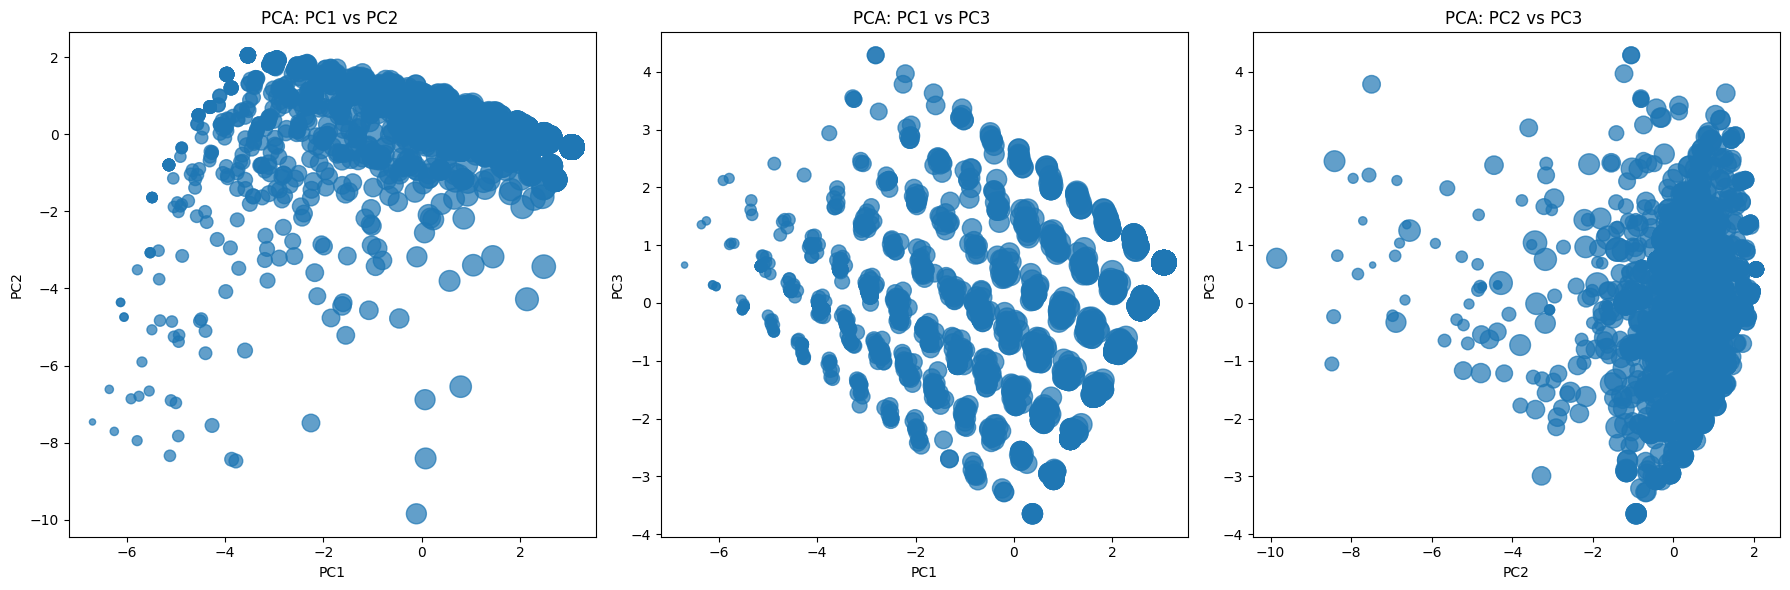

In [66]:
import matplotlib.pyplot as plt
import itertools

# Normaliza o tamanho dos pontos (tamanho proporcional ao accuracy)
min_size = 20
max_size = 300

acc_norm = (accuracy - accuracy.min()) / (accuracy.max() - accuracy.min())
sizes = min_size + acc_norm * (max_size - min_size)

# Combinações 2D entre PC1, PC2 e PC3
pc_pairs = list(itertools.combinations(["PC1", "PC2", "PC3"], 2))

# Criação da figura com subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (pc_x, pc_y) in zip(axes, pc_pairs):
    
    
    ax.scatter(
        pca_df[pc_x],
        pca_df[pc_y],
        s=sizes,
        alpha=0.7
    )
    
    ax.set_xlabel(pc_x)
    ax.set_ylabel(pc_y)
    ax.set_title(
        f"PCA: {pc_x} vs {pc_y} "
    )

plt.tight_layout()
plt.show()



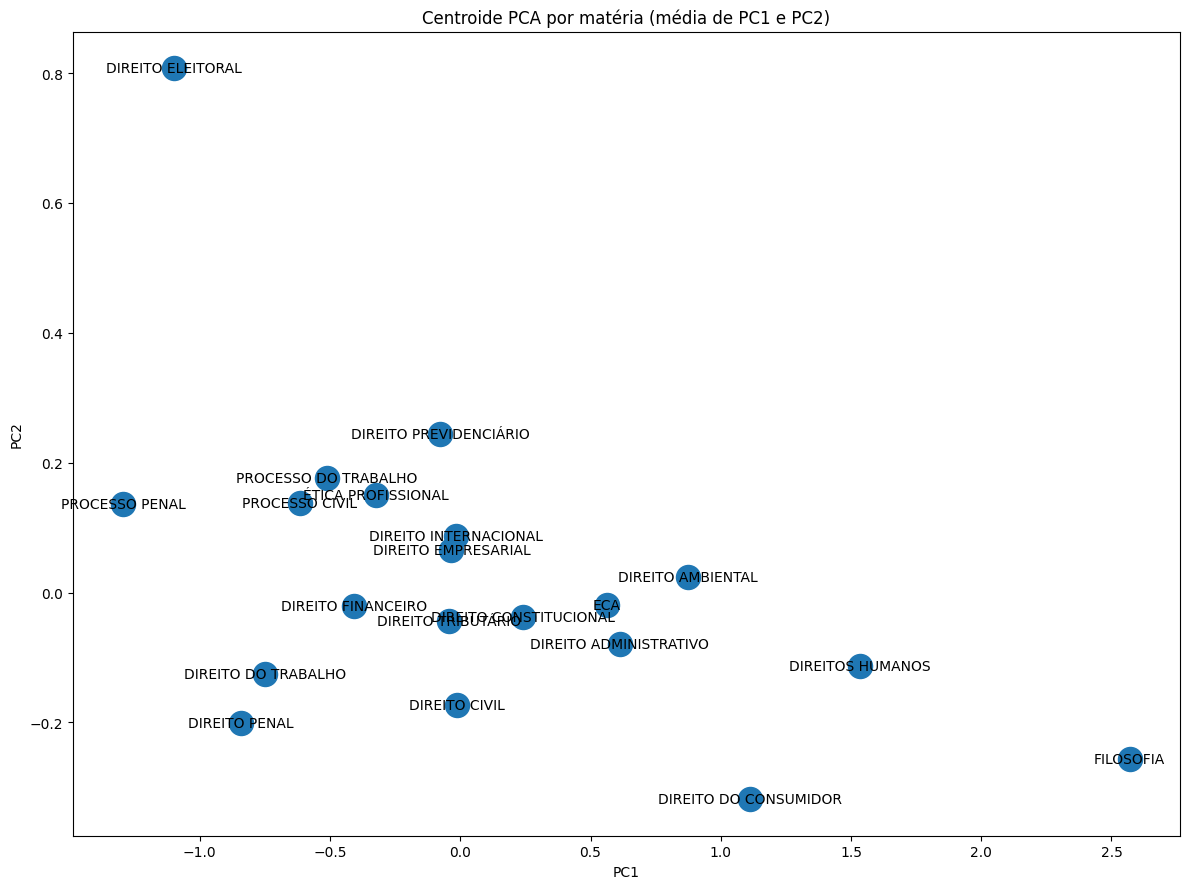

In [67]:
import matplotlib.pyplot as plt

# Alinha matéria com PCA
materia = question_wide_df.loc[pca_df.index, "materia"]

# Cria DataFrame combinado
plot_df = pca_df[["PC1", "PC2"]].copy()
plot_df["materia"] = materia.values

# Calcula média por matéria
centroids = (
    plot_df
    .groupby("materia")[["PC1", "PC2"]]
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(12, 9))
plt.scatter(
    centroids["PC1"],
    centroids["PC2"],
    s=300
)

# Anota o nome da matéria em cada ponto
for _, row in centroids.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        row["materia"],
        fontsize=10,
        ha="center",
        va="center"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Centroide PCA por matéria (média de PC1 e PC2)")
plt.tight_layout()

plt.savefig("../reports/pca_centroides_materia.pdf", bbox_inches="tight")

plt.show()



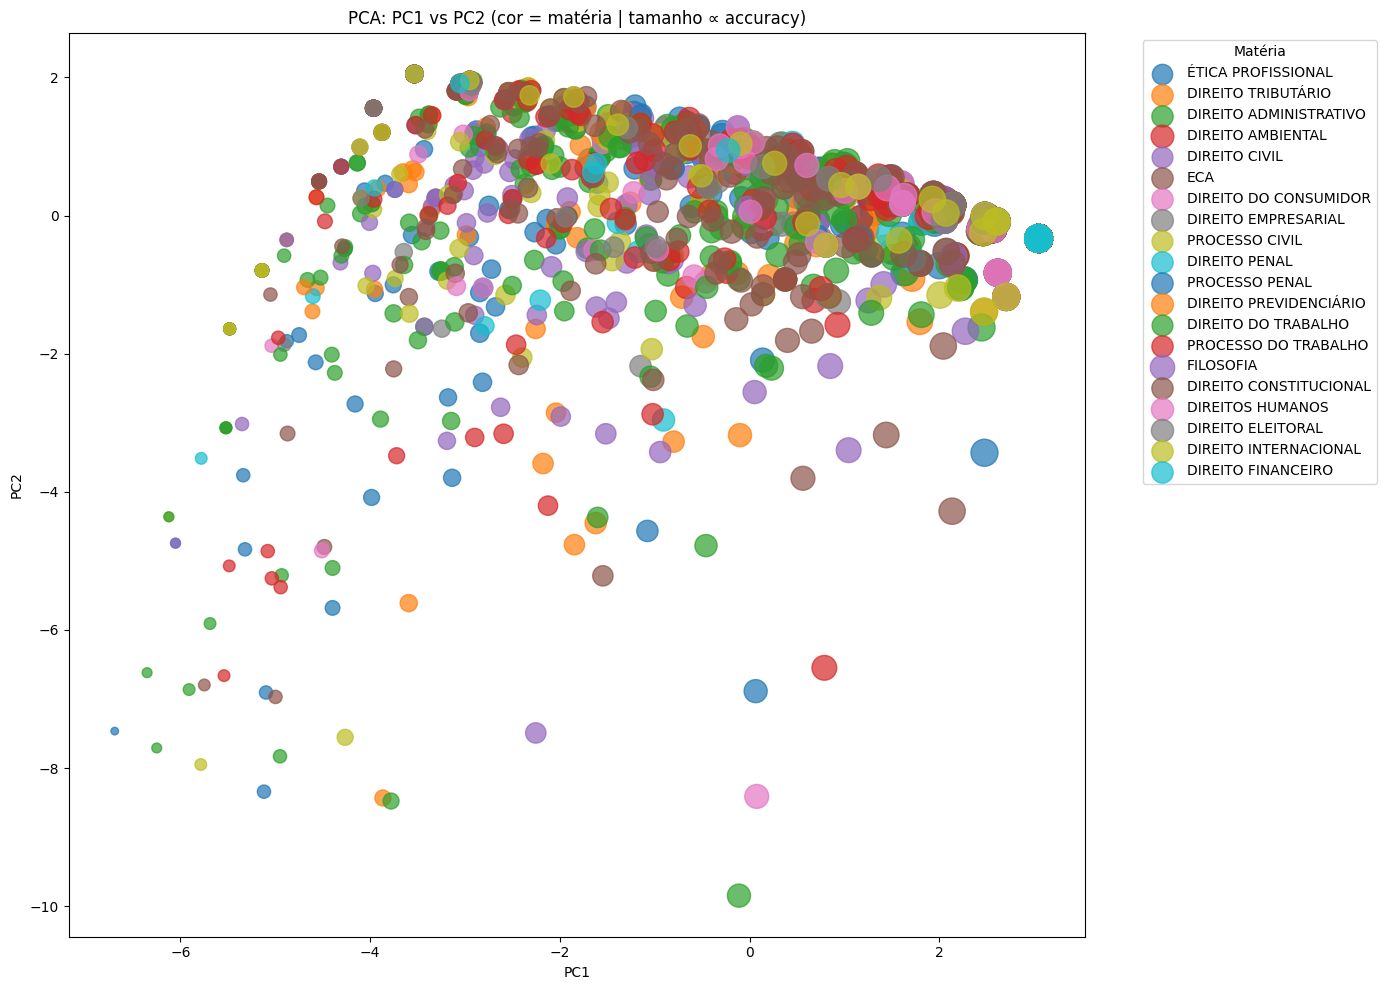

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# Alinha metadados
materia = question_wide_df.loc[pca_df.index, "materia"]

# --- cálculo do accuracy (se ainda não estiver no escopo) ---
metadata_cols = ["question_id", "materia"]
response_cols = question_wide_df.drop(columns=metadata_cols)
accuracy = response_cols.eq(True).sum(axis=1) / response_cols.shape[1]

# --- normalização do tamanho dos pontos ---
min_size = 30
max_size = 400

acc_norm = (accuracy - accuracy.min()) / (accuracy.max() - accuracy.min())
sizes = min_size + acc_norm * (max_size - min_size)

# --- plot ---
plt.figure(figsize=(14, 10))

for m in materia.unique():
    mask = materia == m
    plt.scatter(
        pca_df.loc[mask, "PC1"],
        pca_df.loc[mask, "PC2"],
        s=sizes[mask],
        alpha=0.7,
        label=m
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: PC1 vs PC2 (cor = matéria | tamanho ∝ accuracy)")

plt.legend(
    title="Matéria",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


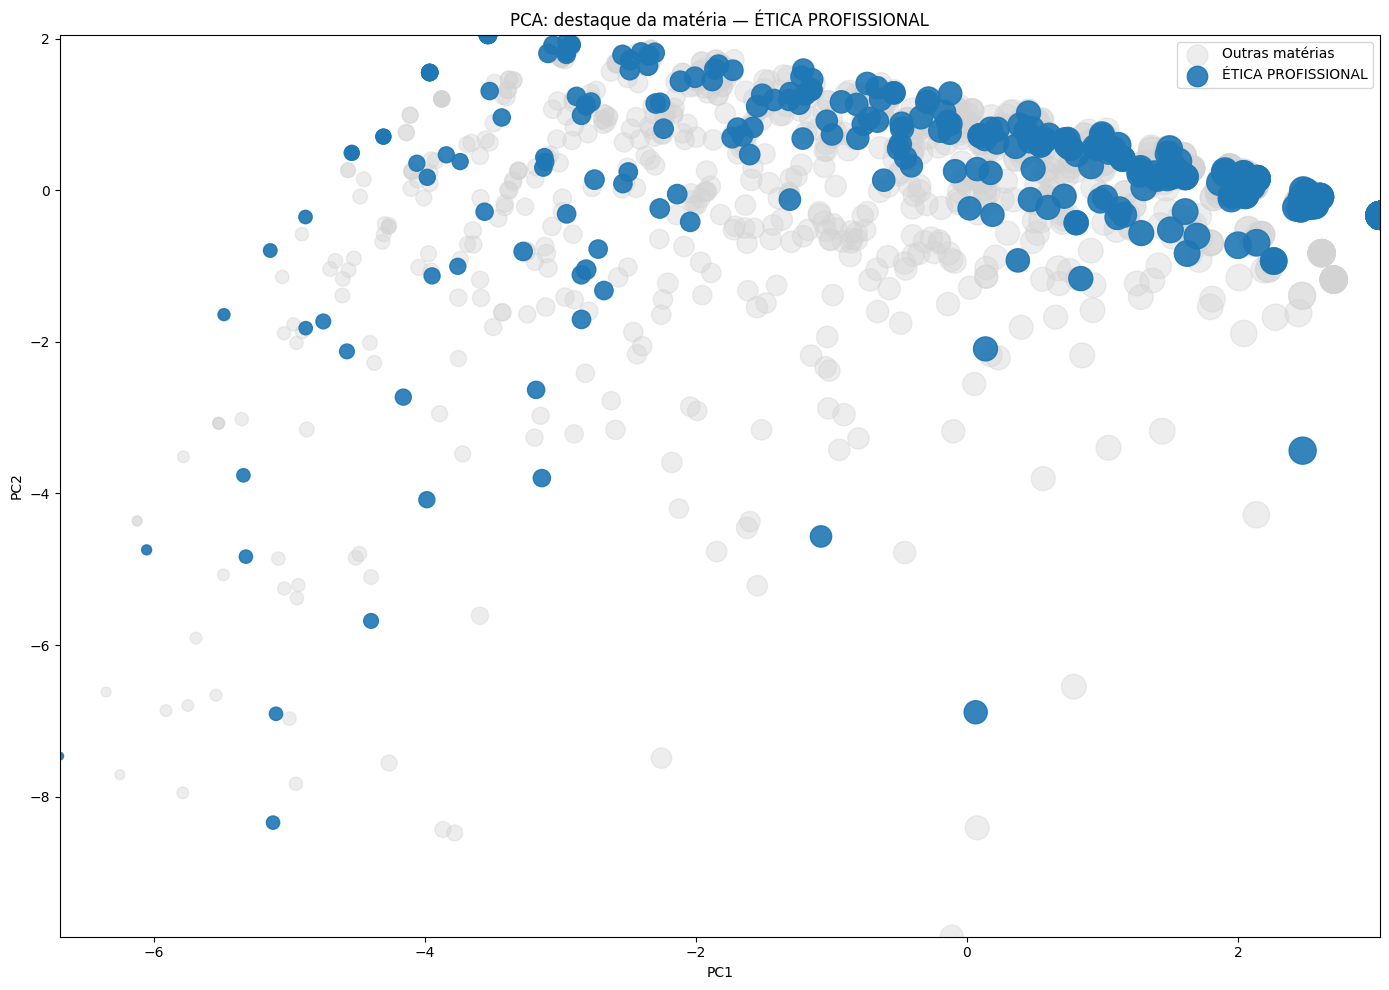

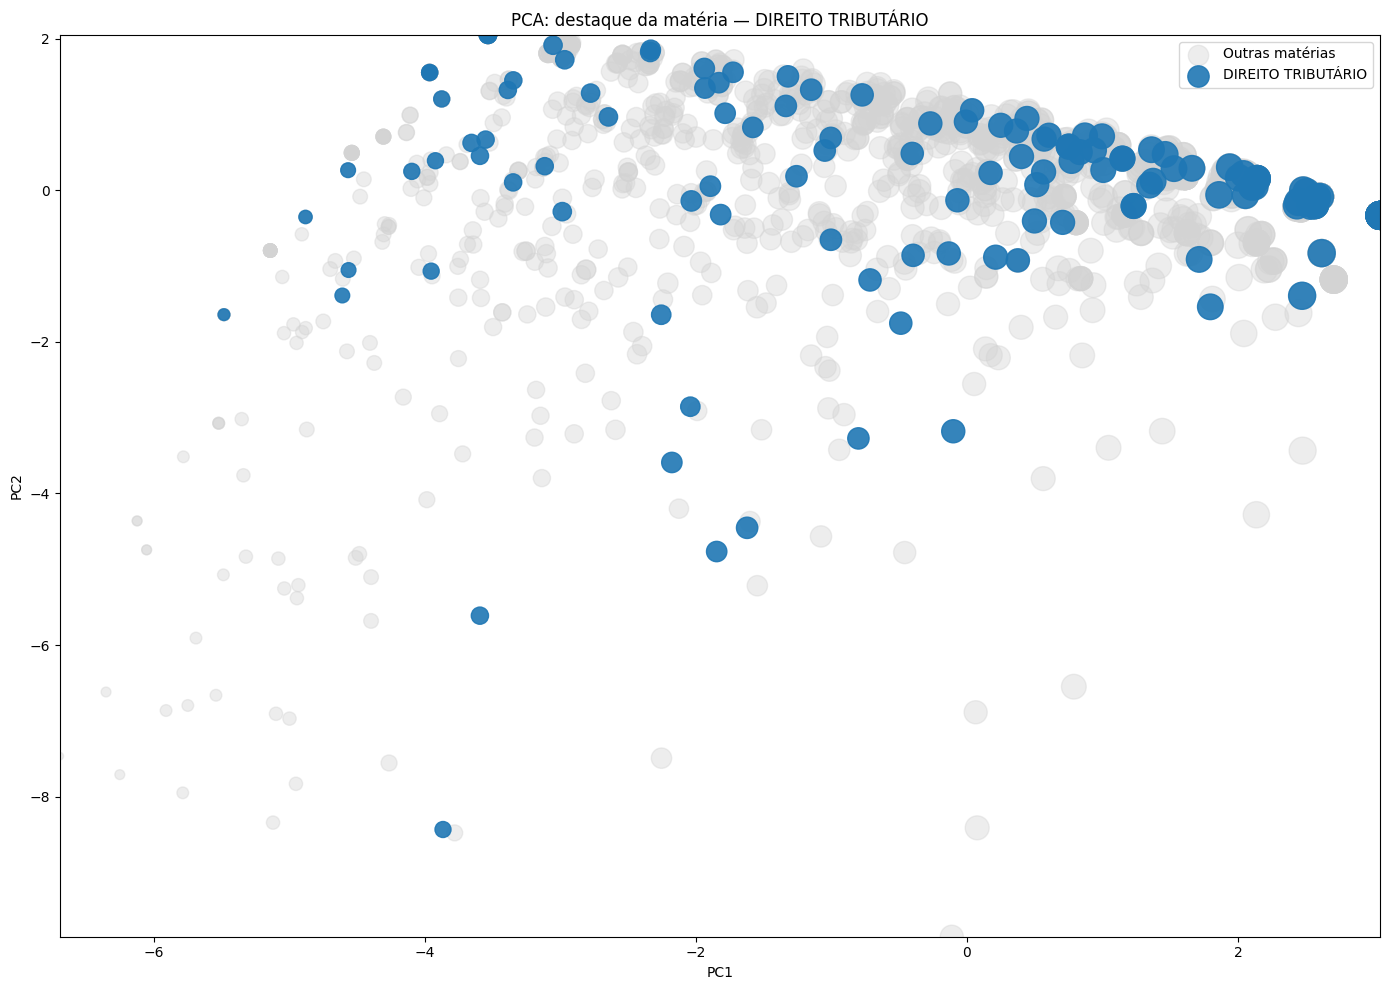

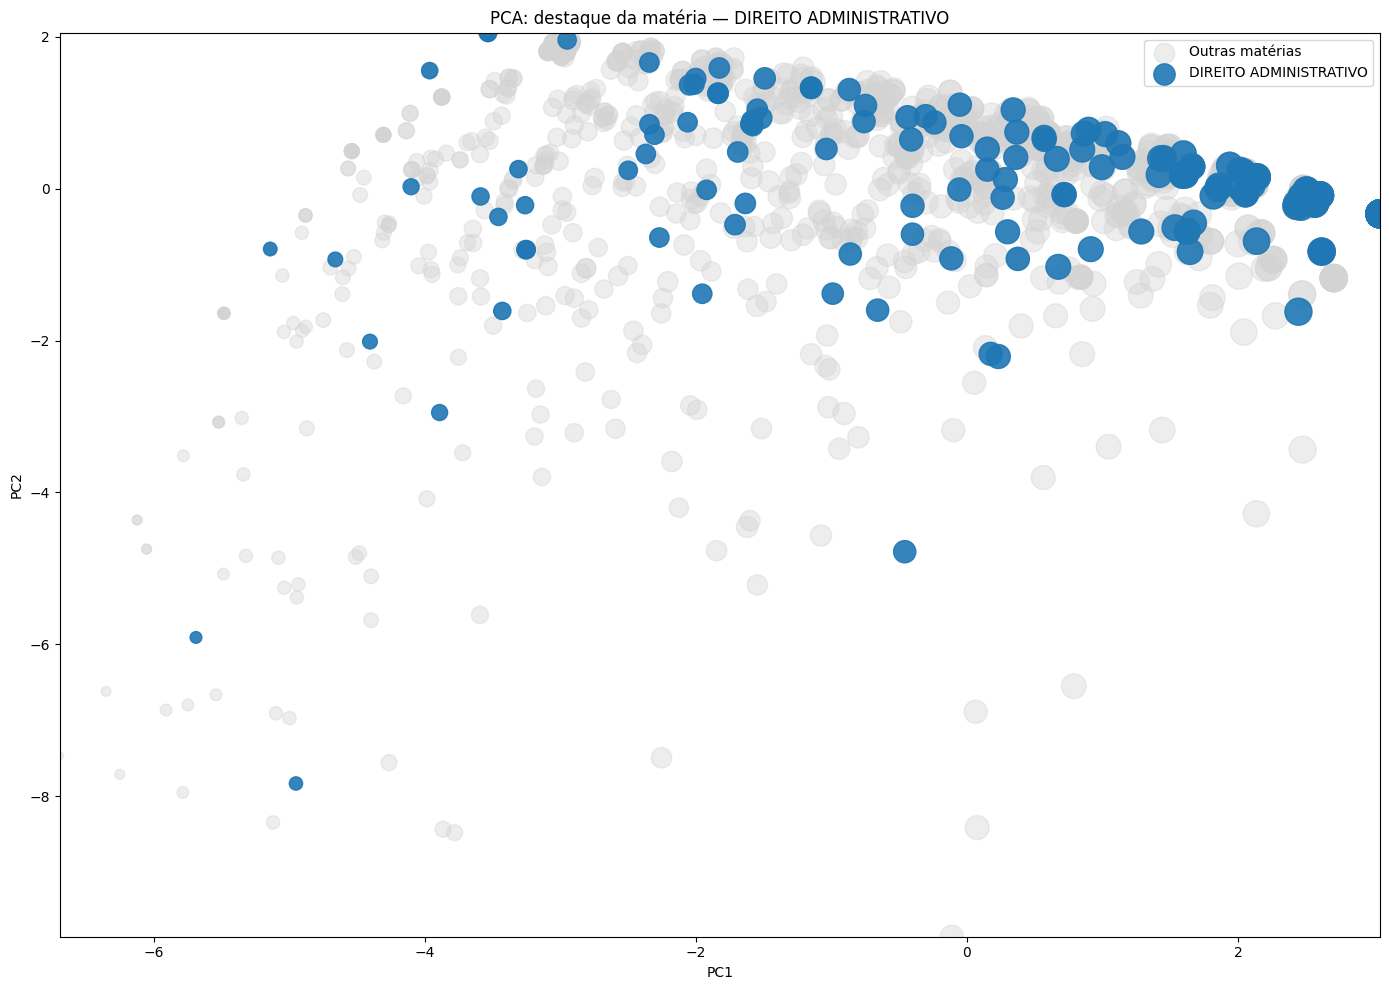

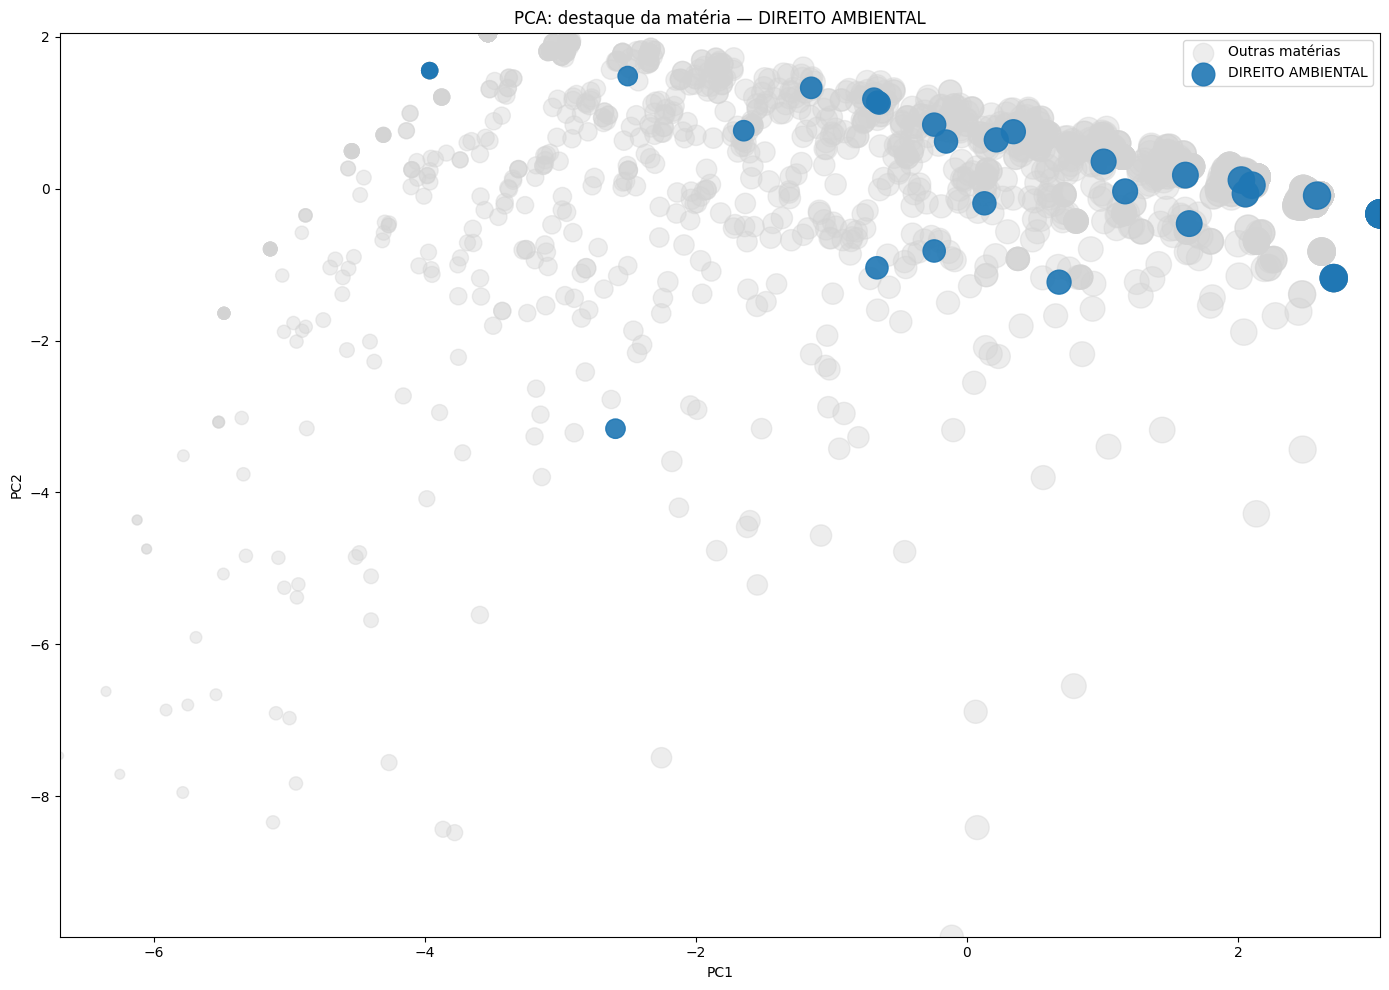

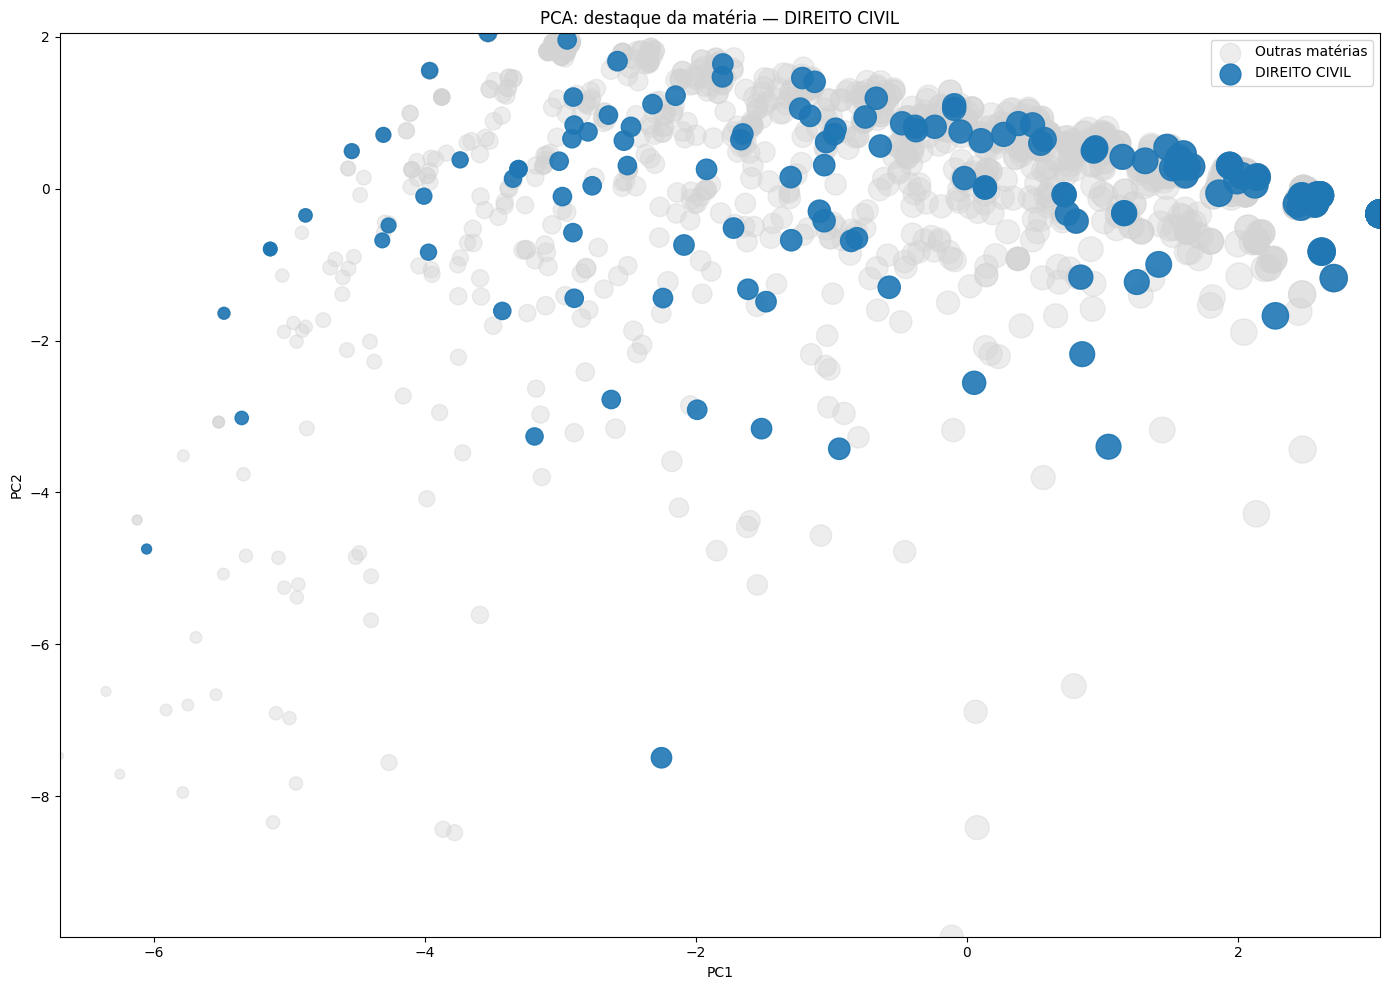

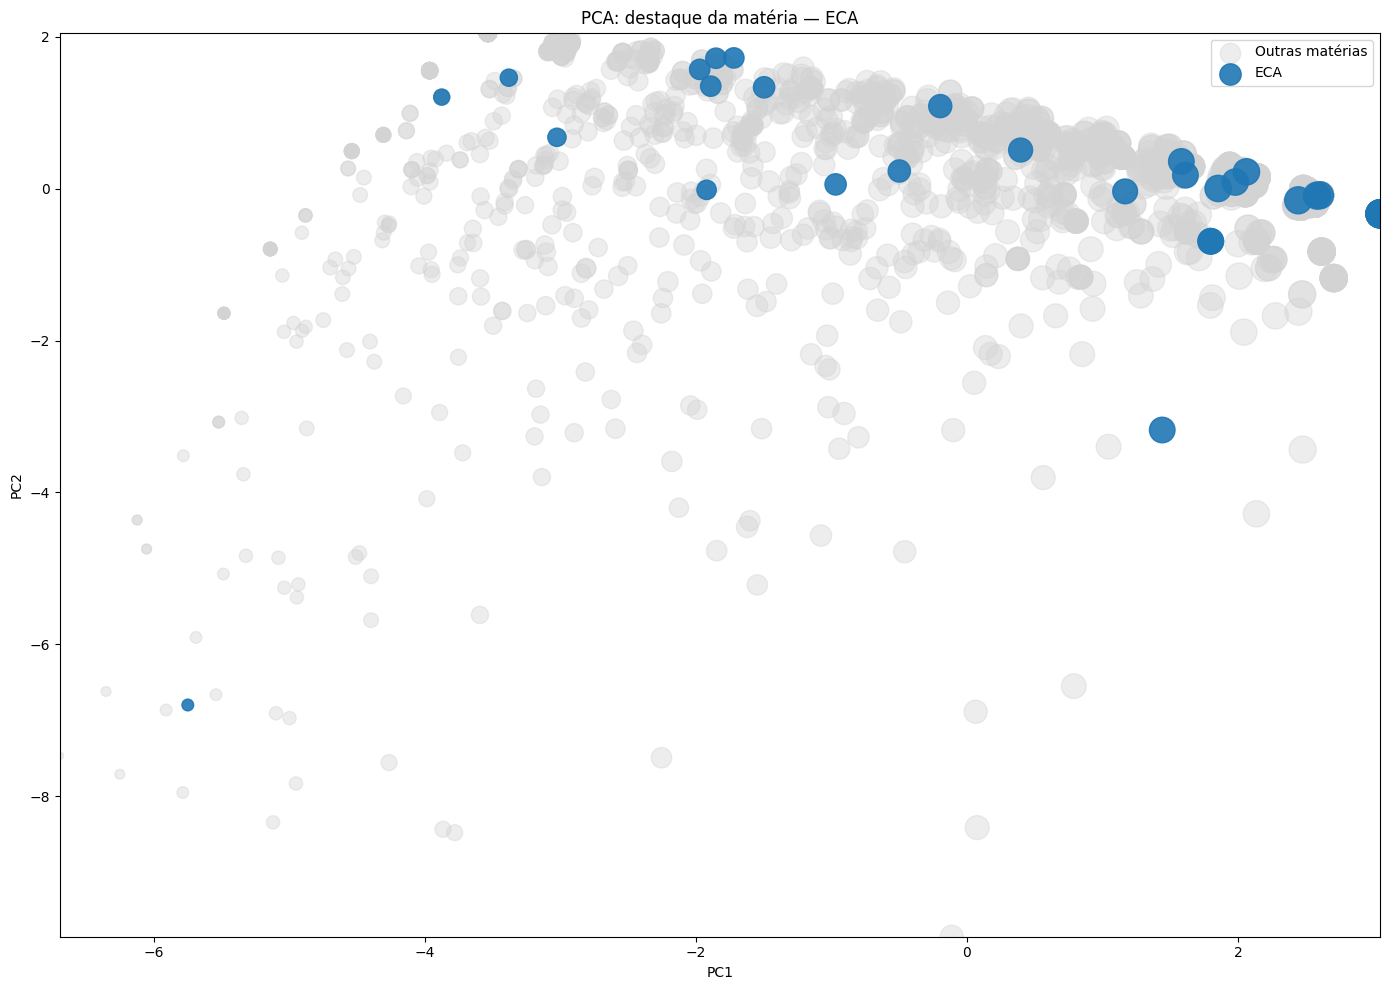

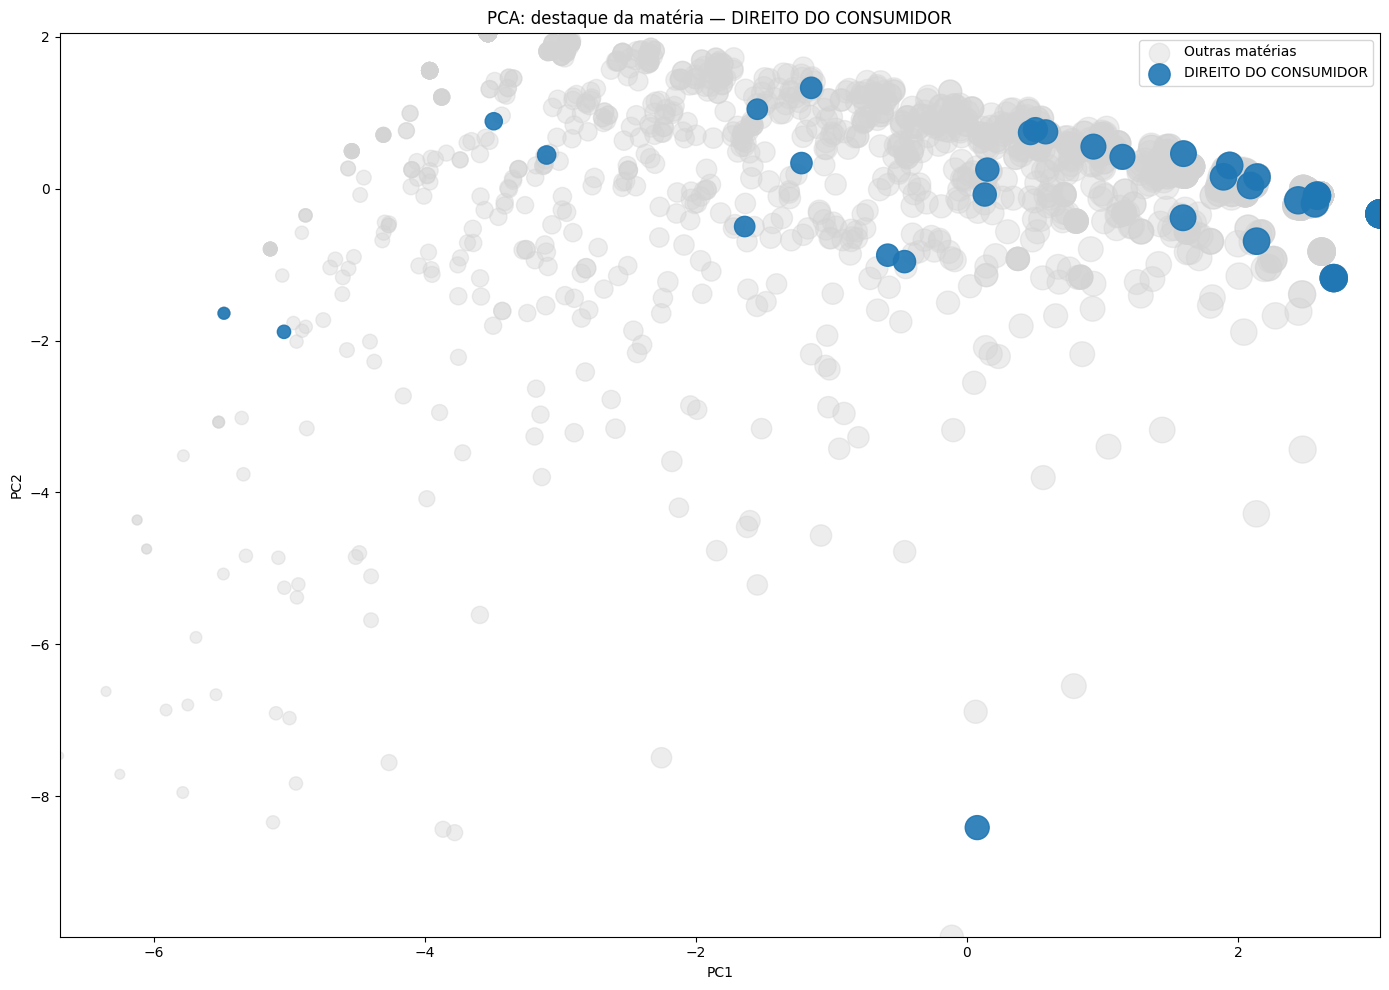

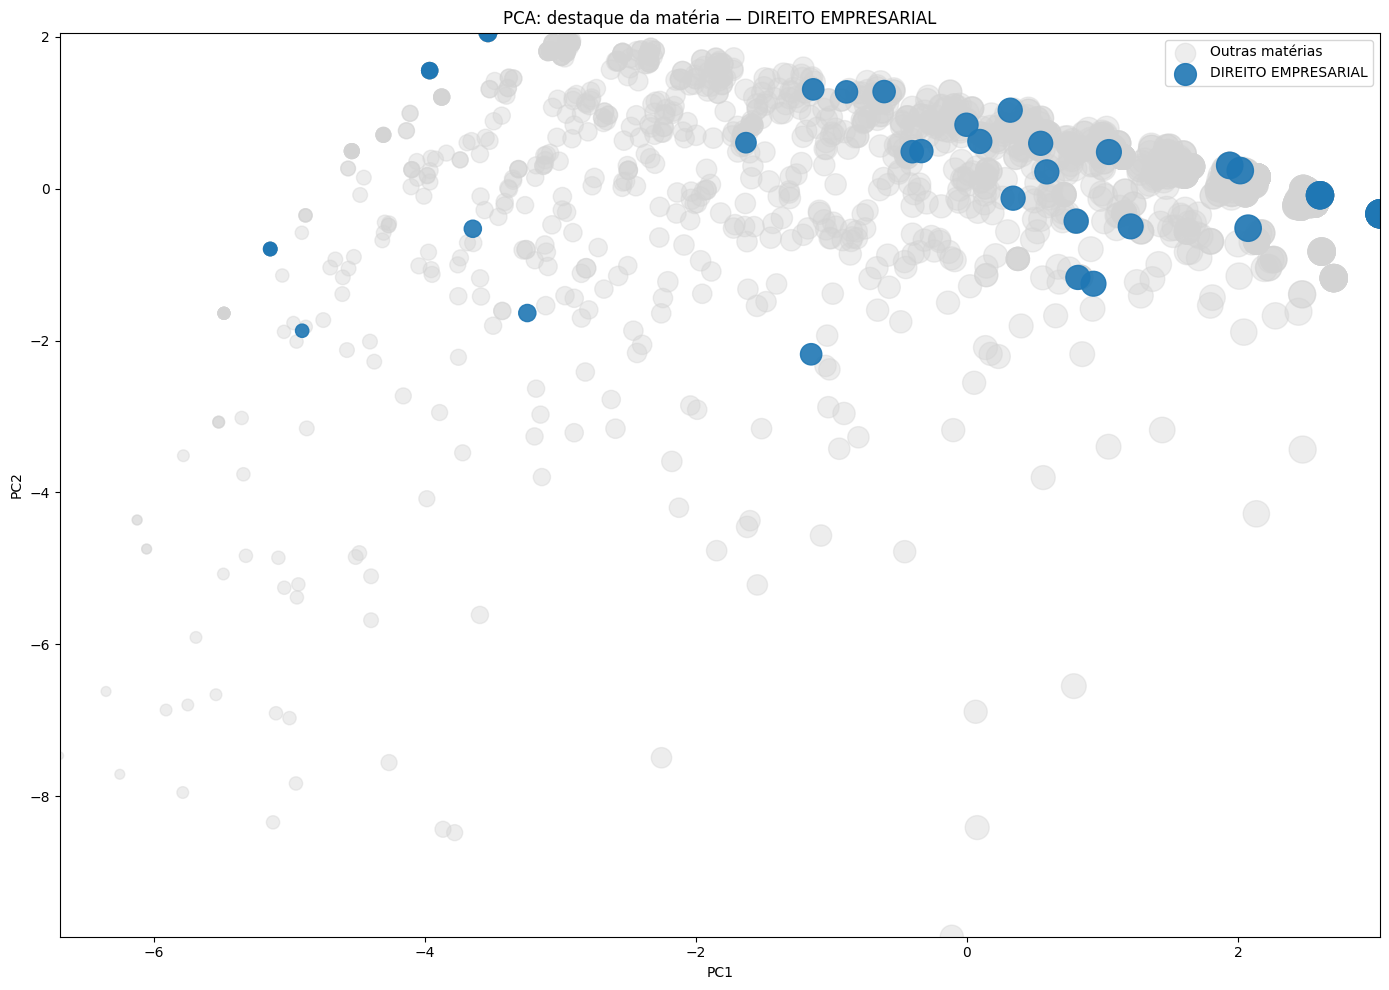

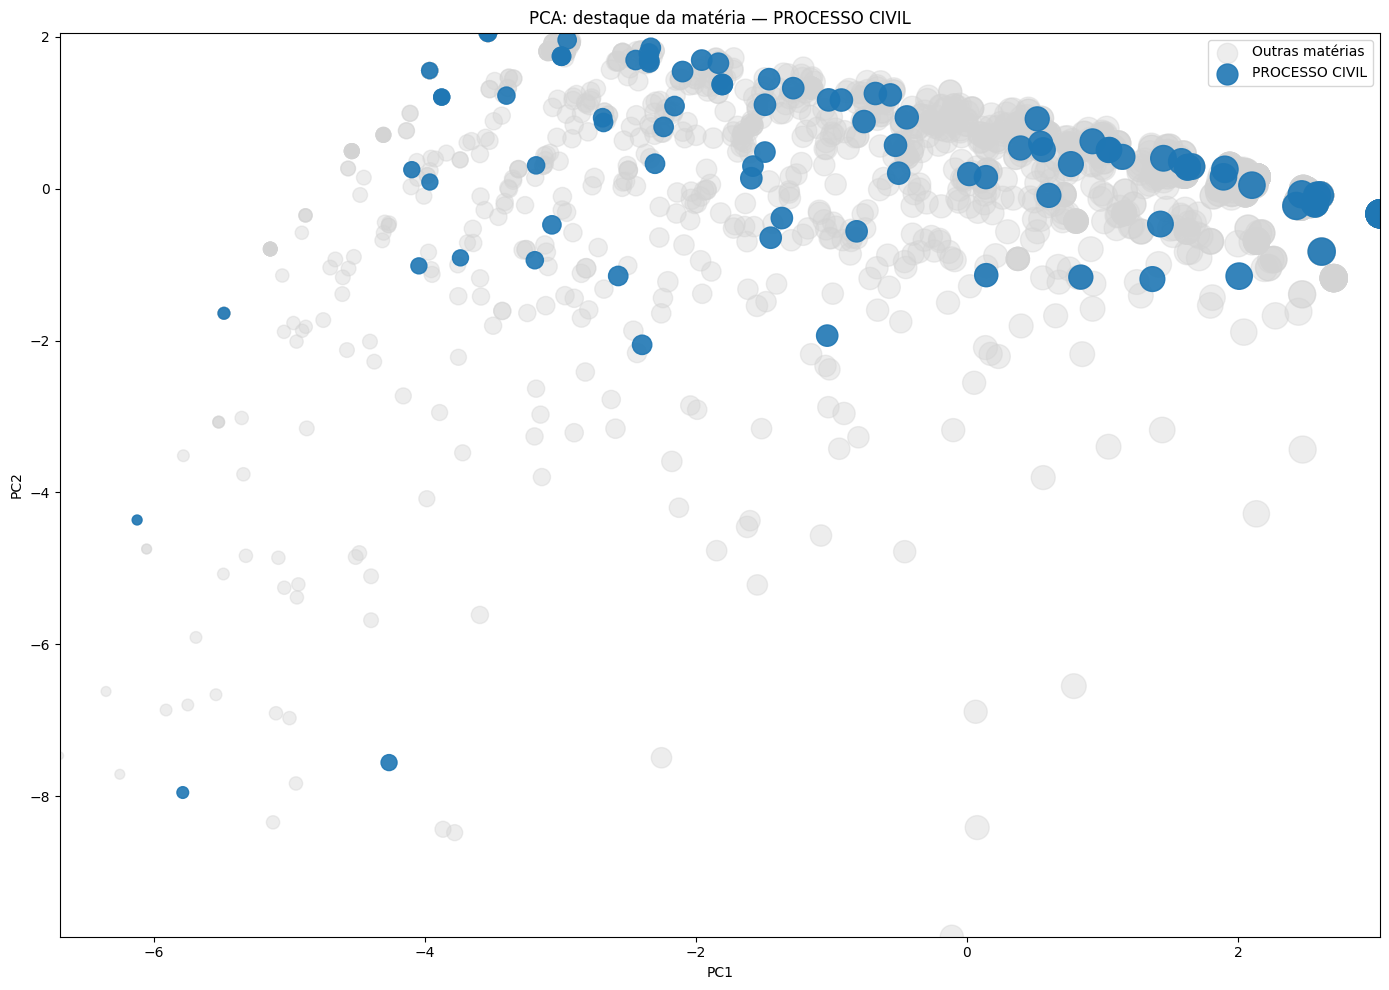

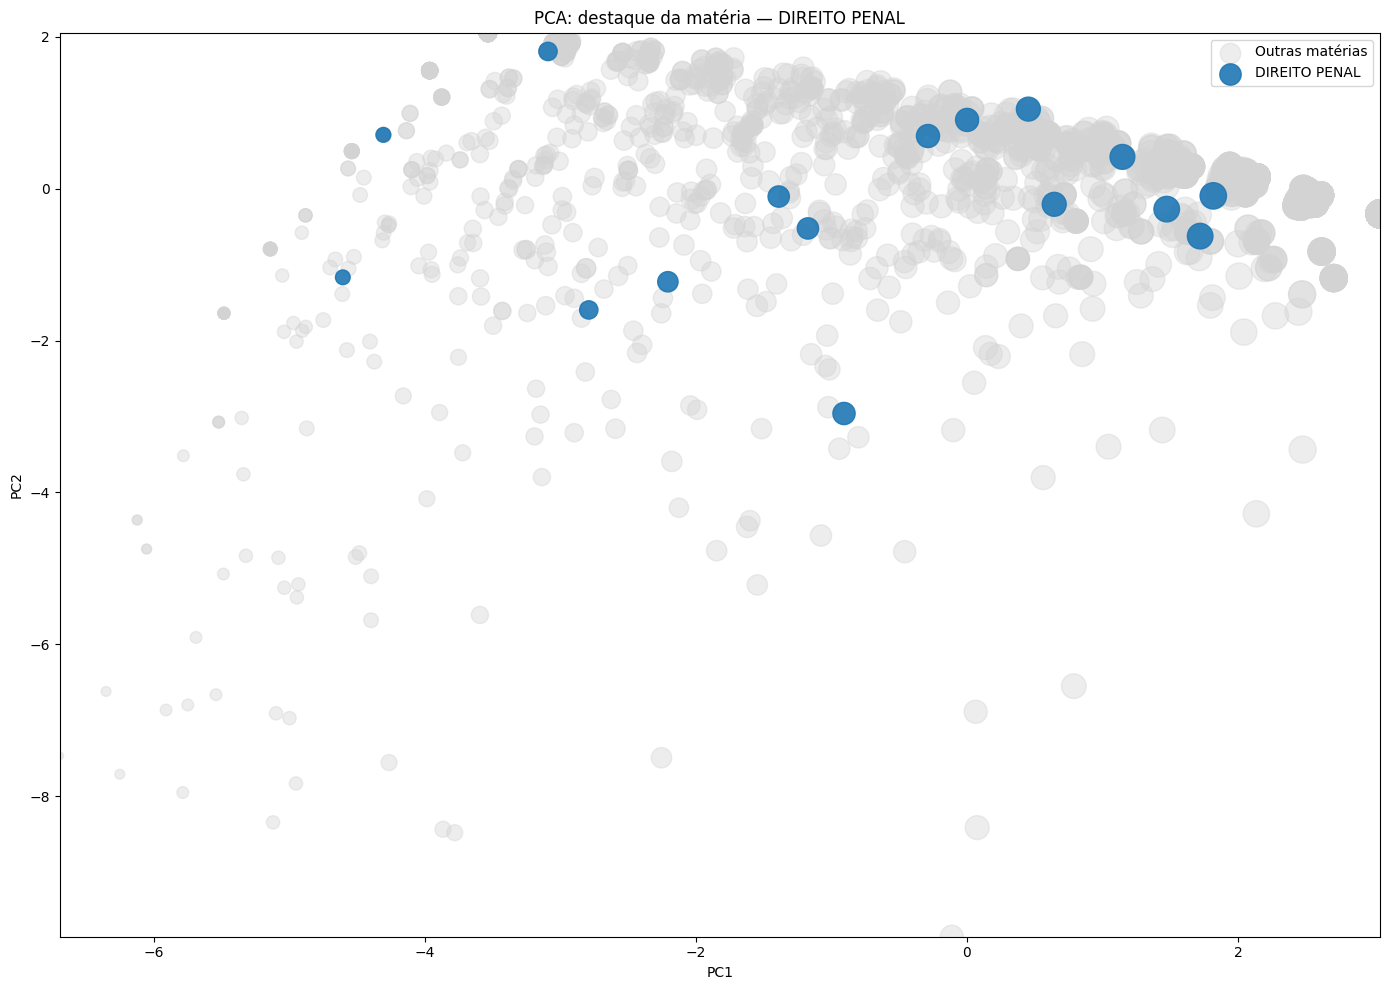

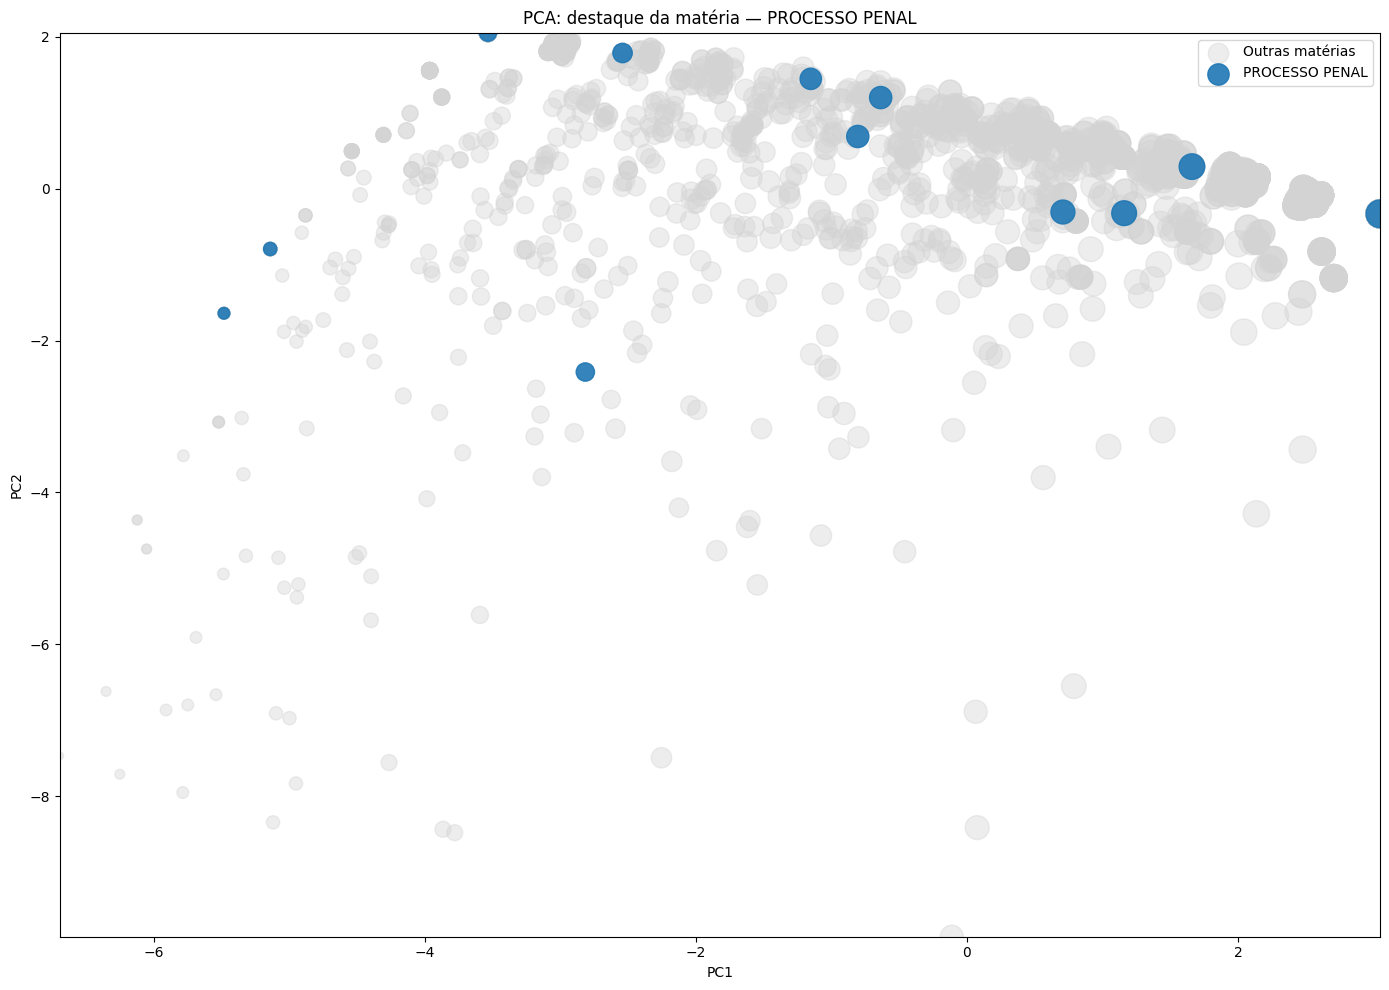

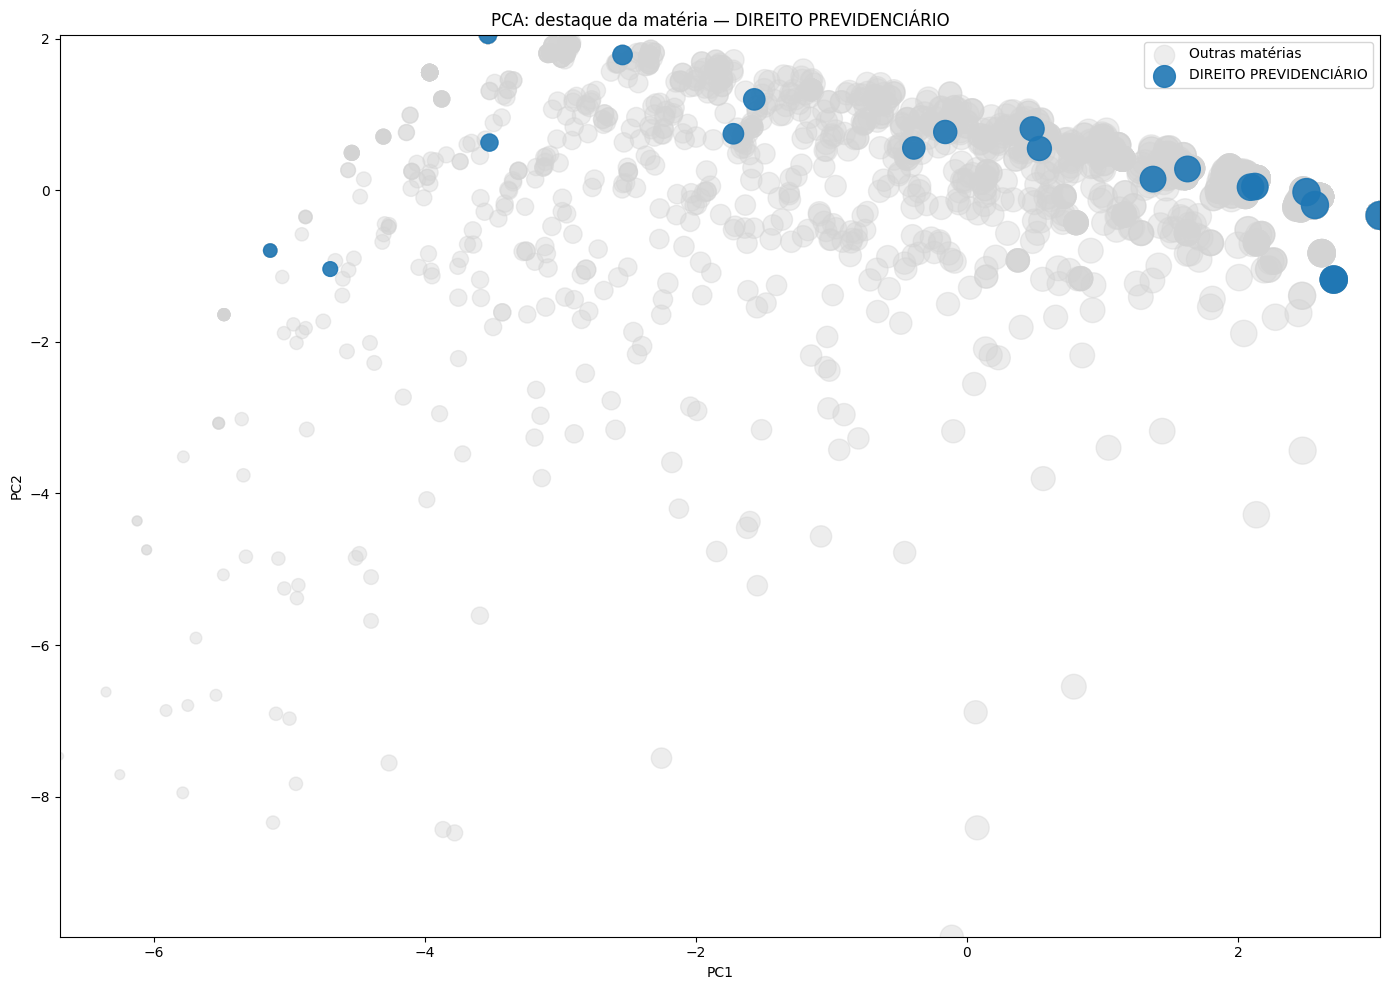

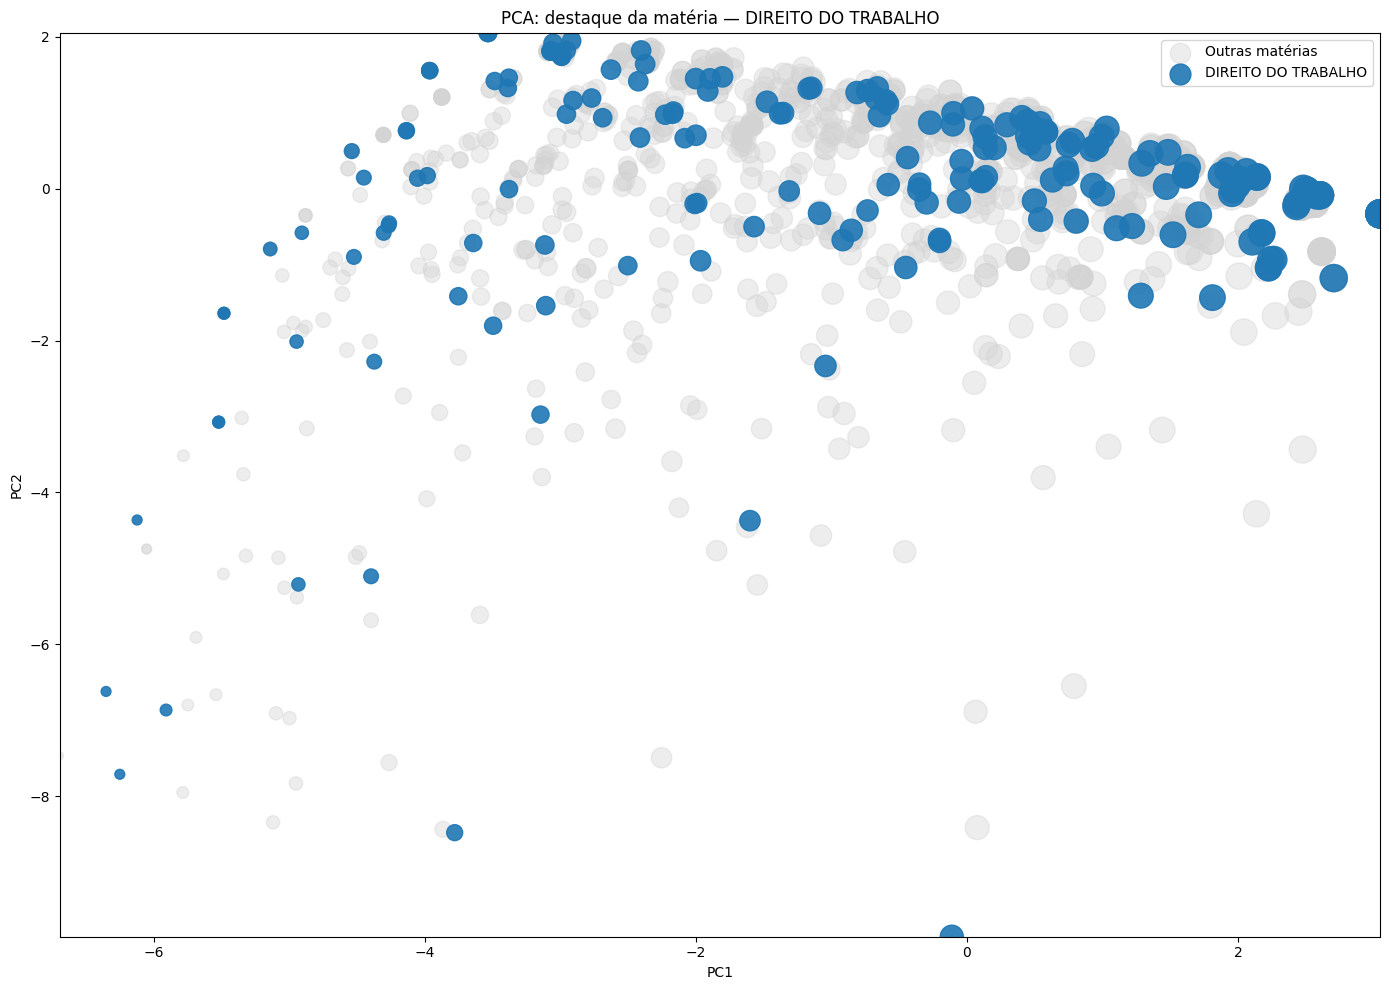

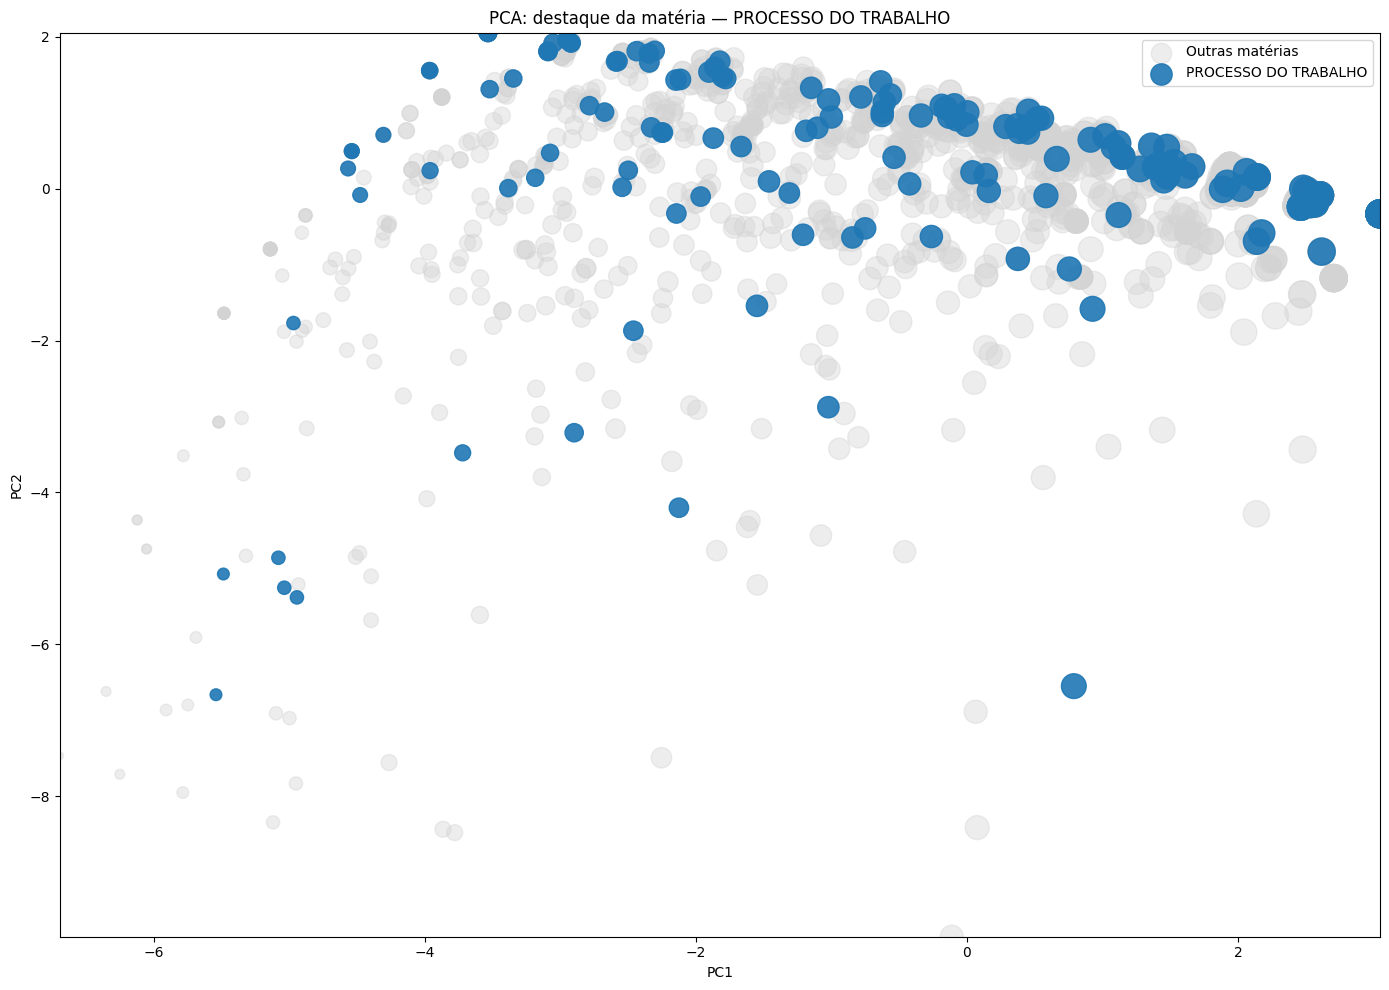

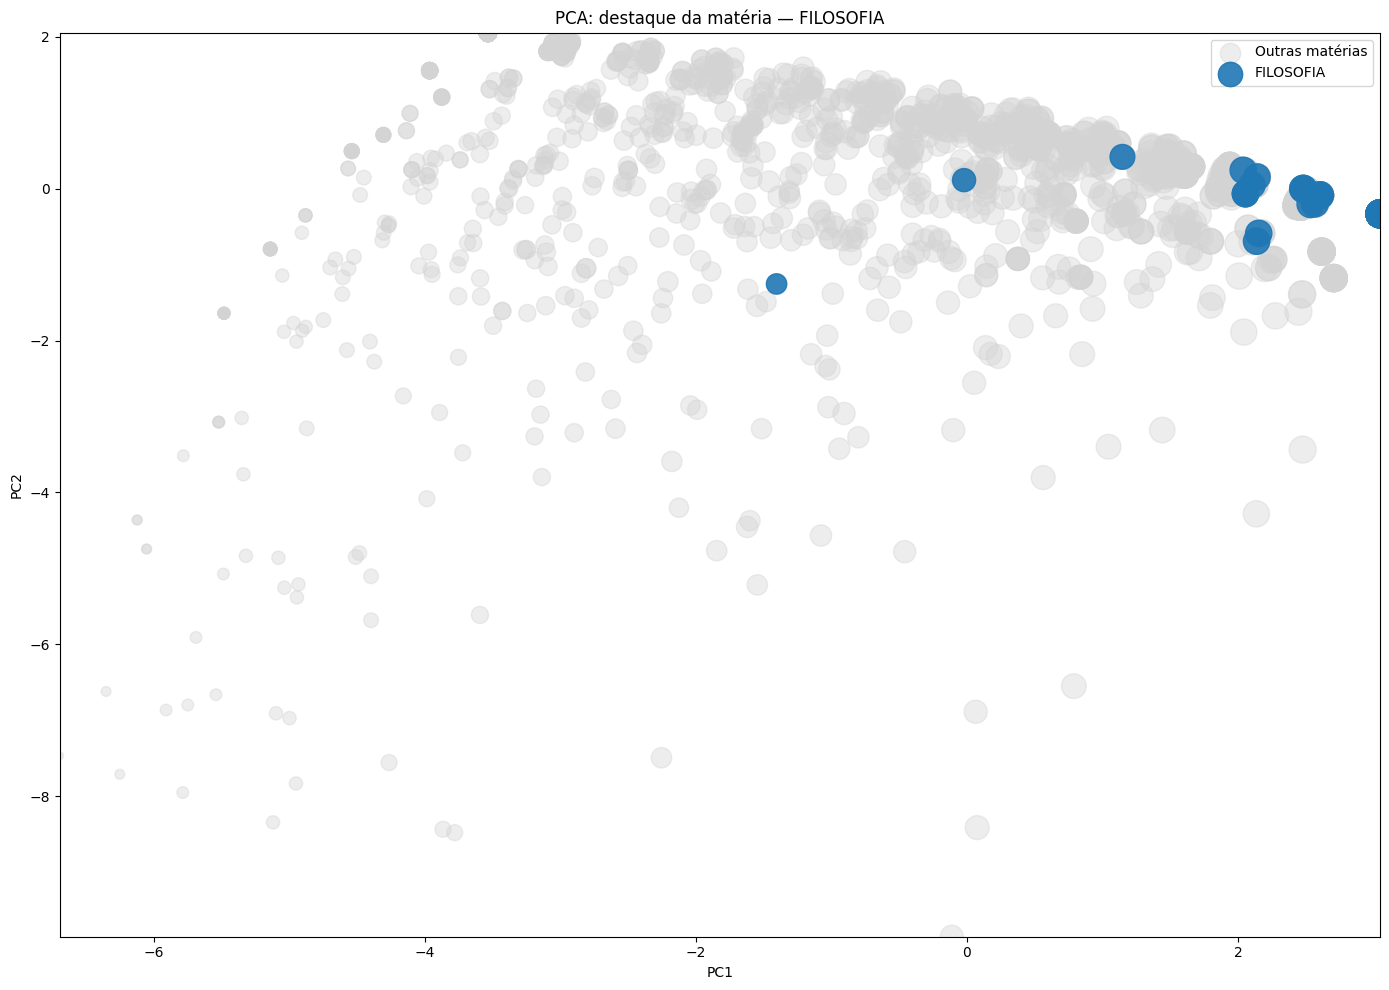

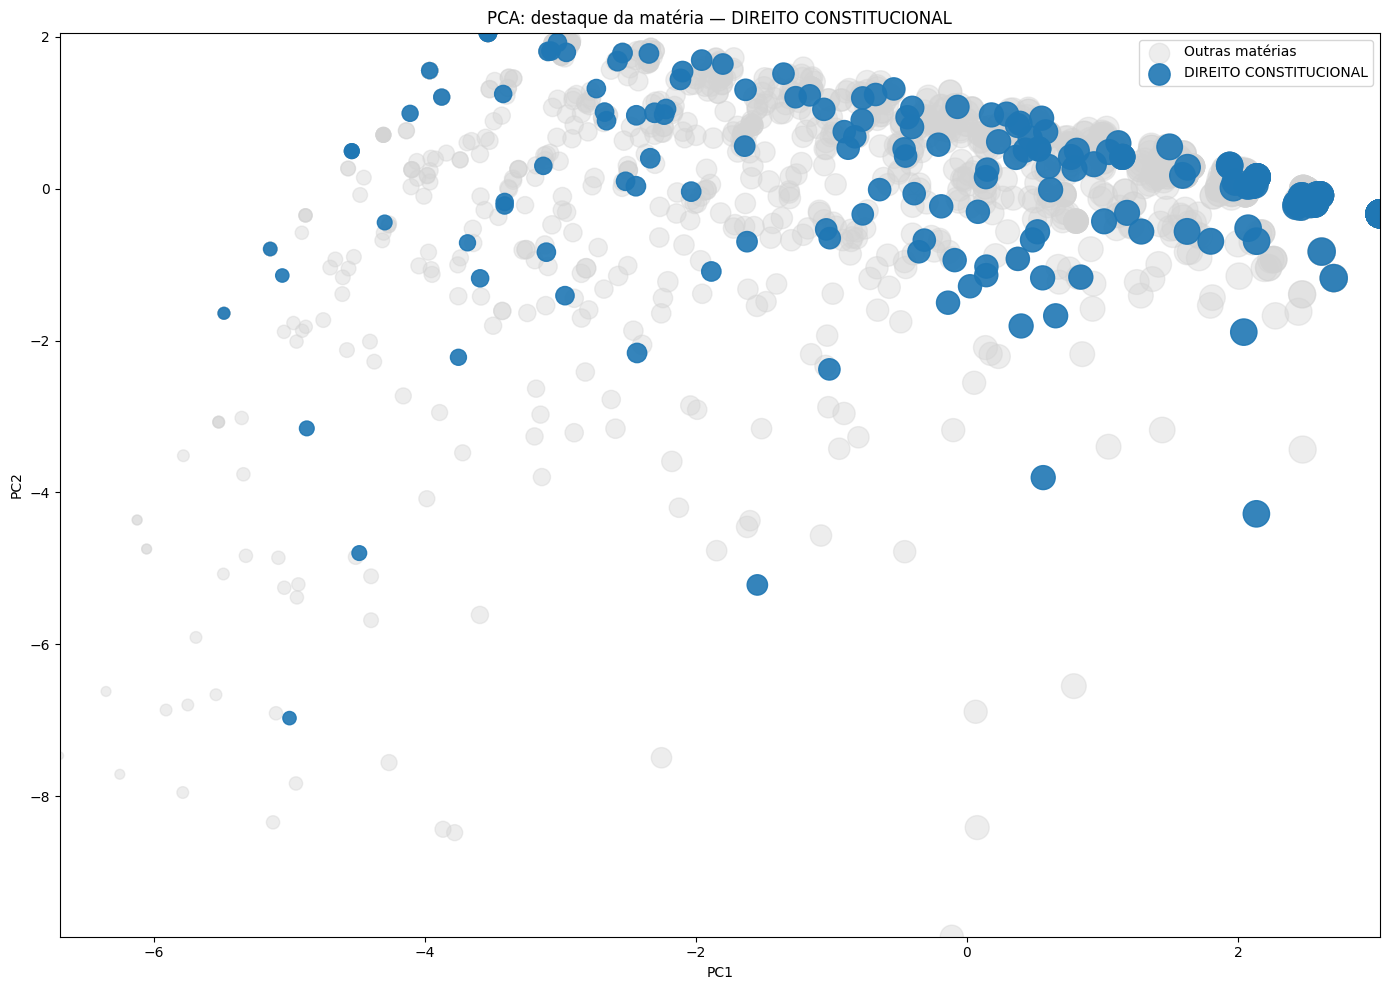

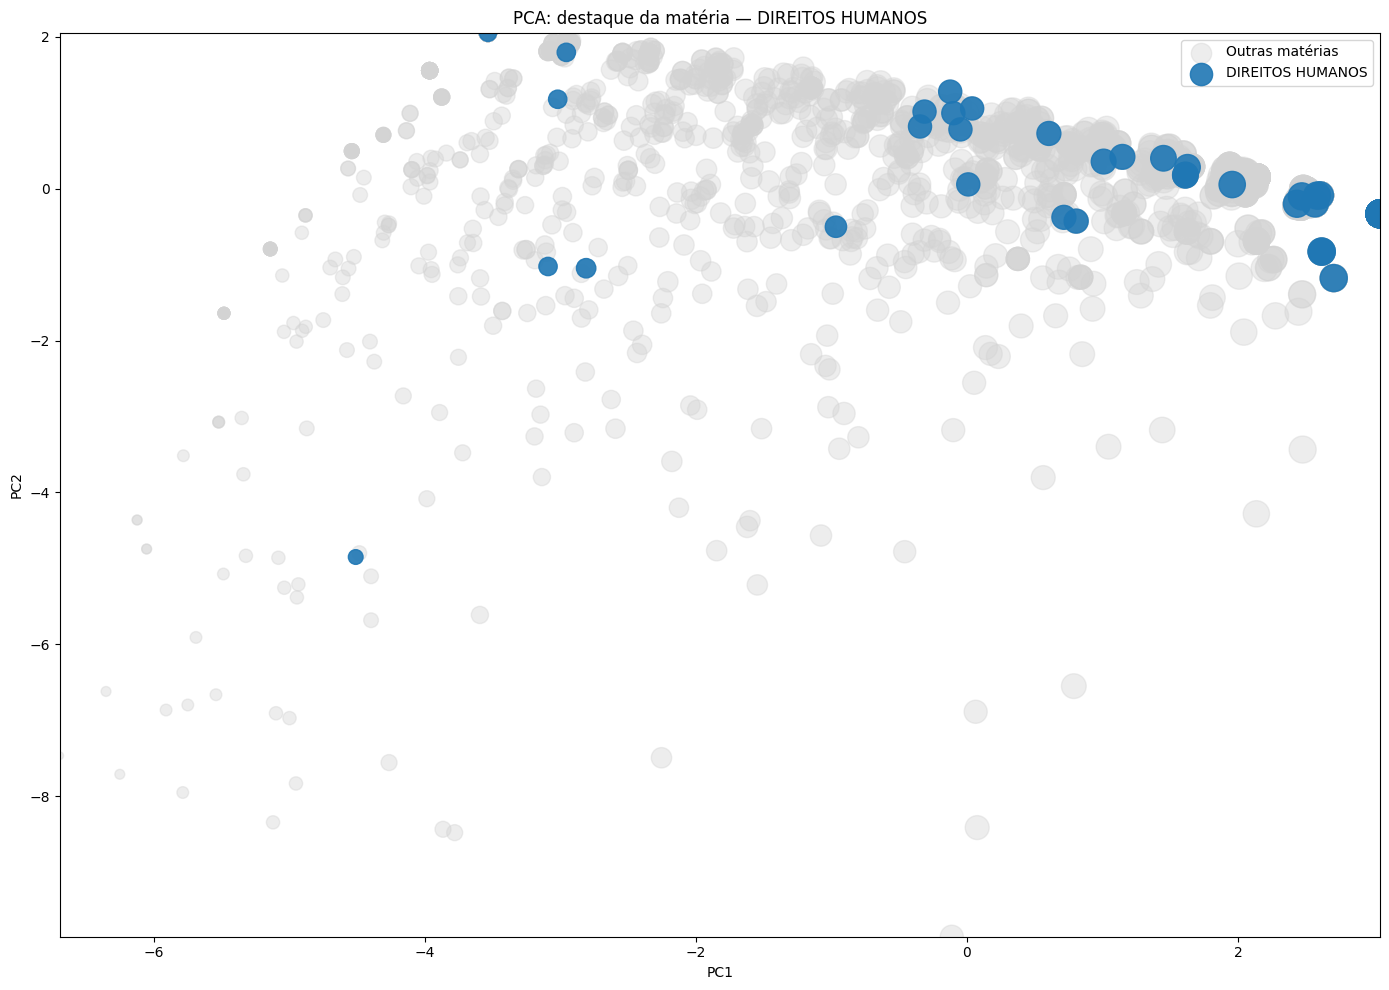

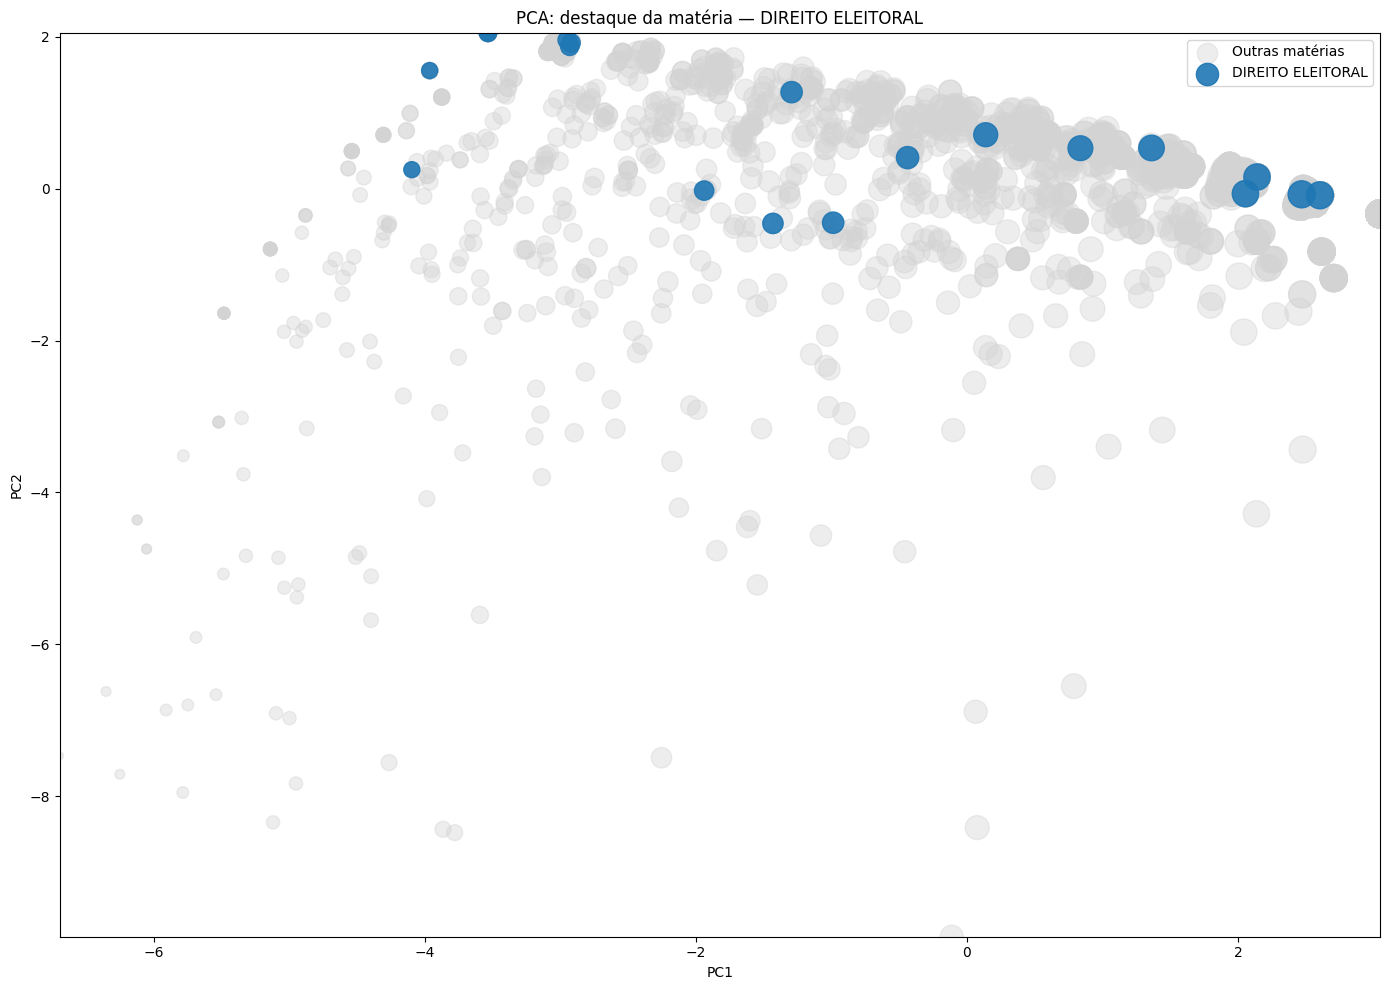

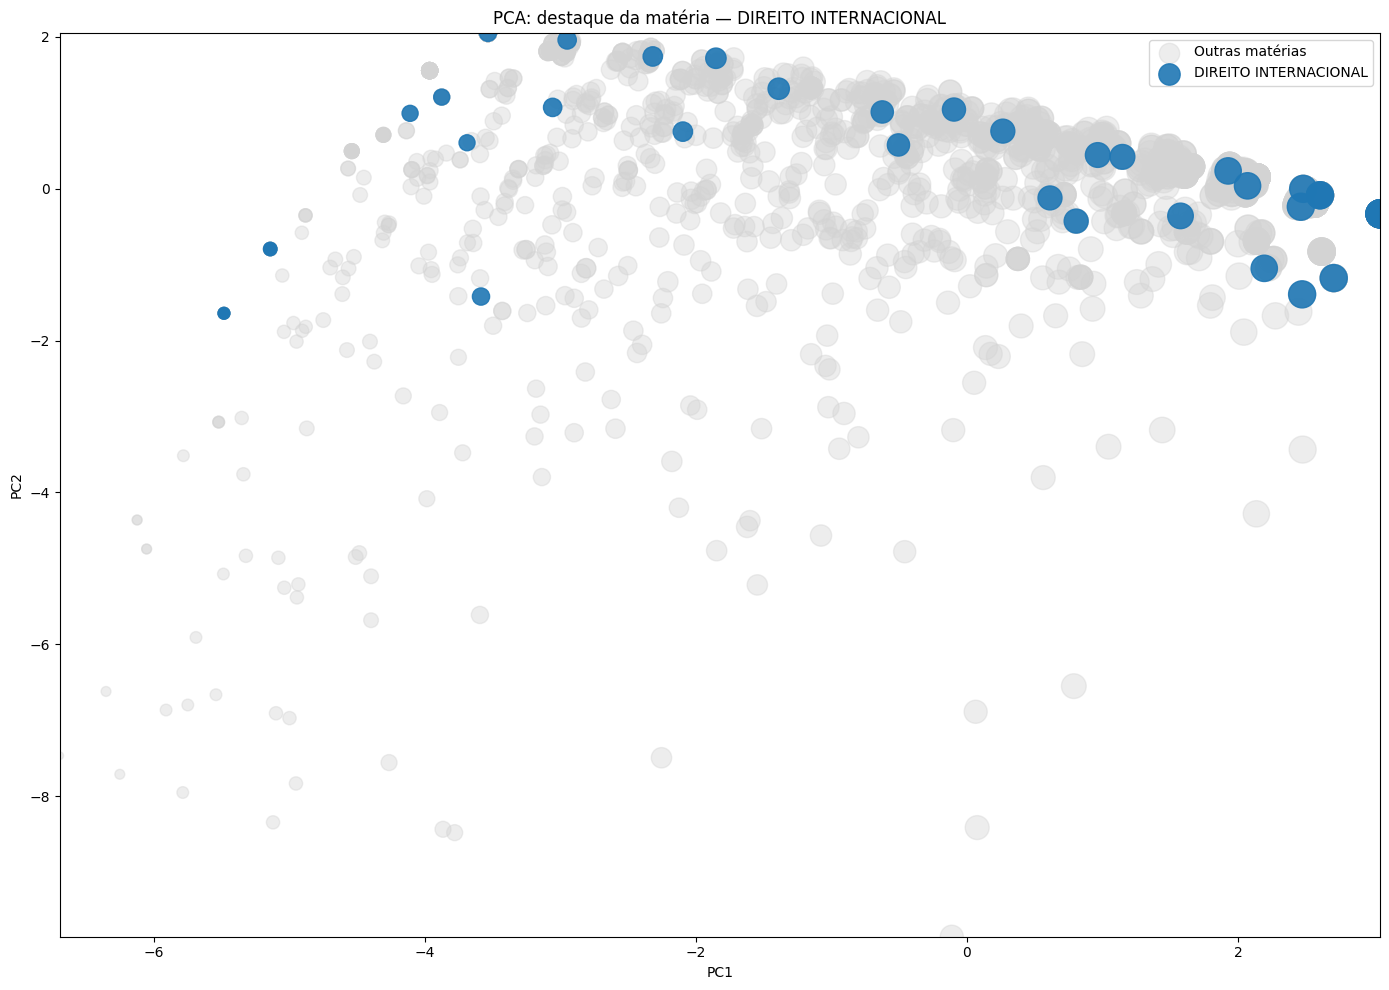

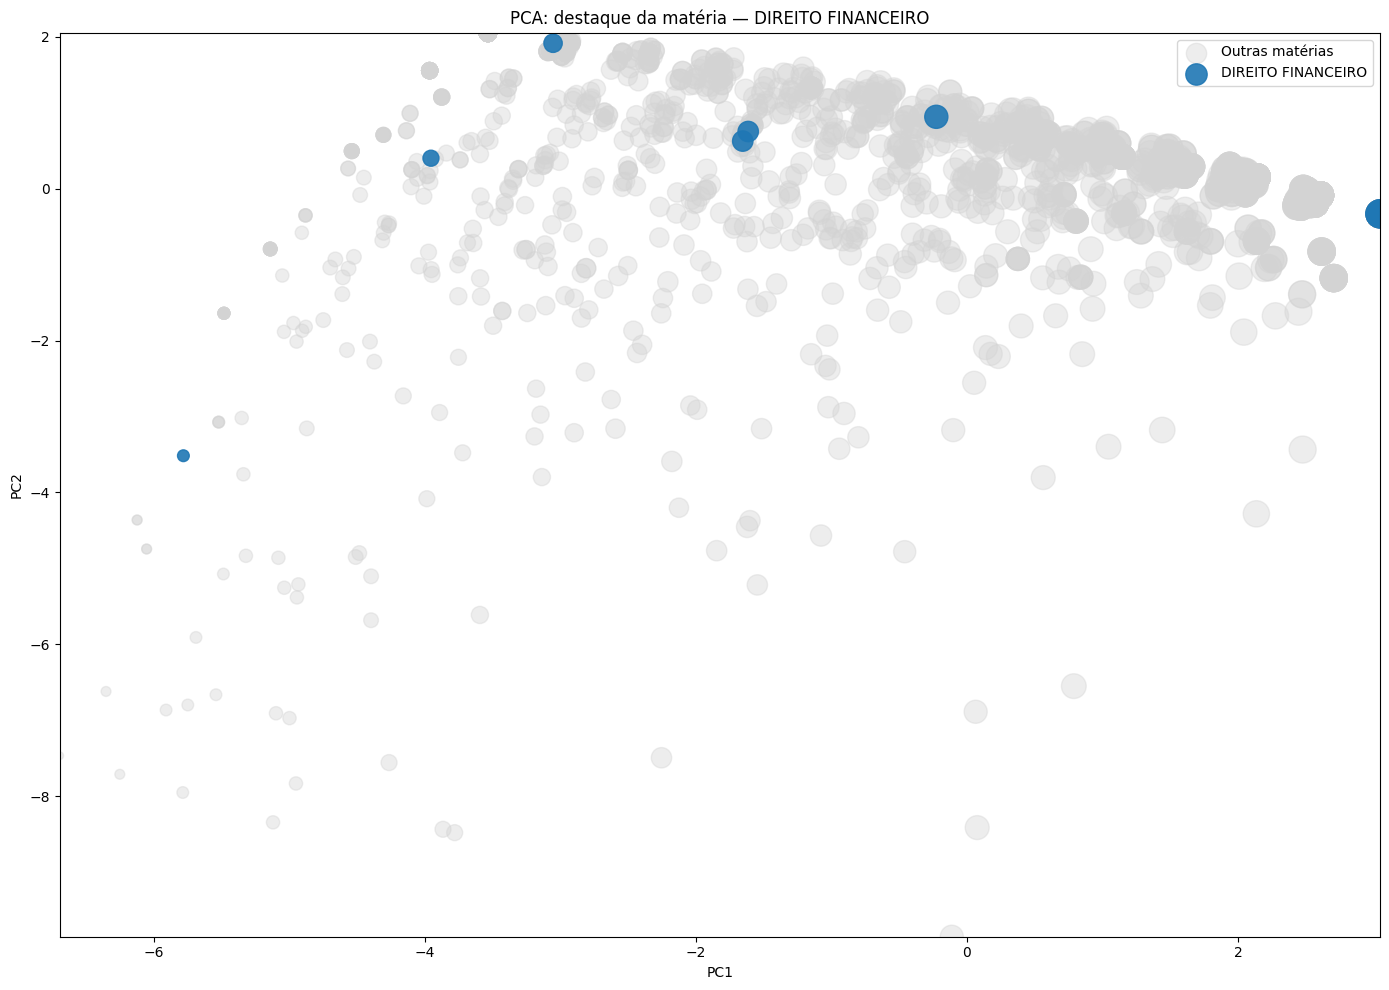

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Alinha metadados
materia = question_wide_df.loc[pca_df.index, "materia"]

# --- cálculo do accuracy ---
metadata_cols = ["question_id", "materia"]
response_cols = question_wide_df.drop(columns=metadata_cols)

accuracy = response_cols.eq(True).sum(axis=1) / response_cols.shape[1]

# --- normalização do tamanho ---
min_size = 30
max_size = 400

acc_norm = (accuracy - accuracy.min()) / (accuracy.max() - accuracy.min())
sizes = min_size + acc_norm * (max_size - min_size)

# --- limites fixos (mesma escala em todos os plots) ---
x_min, x_max = pca_df["PC1"].min(), pca_df["PC1"].max()
y_min, y_max = pca_df["PC2"].min(), pca_df["PC2"].max()

# --- loop por matéria ---
for m in materia.unique():

    plt.figure(figsize=(14, 10))

    # 🔹 outras matérias (cinza)
    other_mask = materia != m
    plt.scatter(
        pca_df.loc[other_mask, "PC1"],
        pca_df.loc[other_mask, "PC2"],
        s=sizes[other_mask],
        color="lightgray",
        alpha=0.4,
        label="Outras matérias"
    )

    # 🔹 matéria em destaque
    highlight_mask = materia == m
    plt.scatter(
        pca_df.loc[highlight_mask, "PC1"],
        pca_df.loc[highlight_mask, "PC2"],
        s=sizes[highlight_mask],
        alpha=0.9,
        label=m
    )

    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"PCA: destaque da matéria — {m}")

    plt.legend()
    plt.tight_layout()
    plt.show()


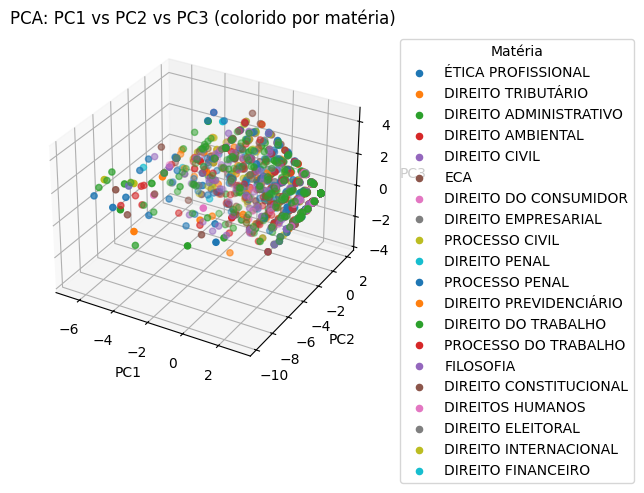

In [70]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

# Alinha a coluna 'materia' ao PCA
materia = question_wide_df.loc[pca_df.index, "materia"]

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

for m in materia.unique():
    mask = materia == m
    ax.scatter(
        pca_df.loc[mask, "PC1"],
        pca_df.loc[mask, "PC2"],
        pca_df.loc[mask, "PC3"],
        label=m
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA: PC1 vs PC2 vs PC3 (colorido por matéria)")

# Legenda fora do gráfico
ax.legend(
    title="Matéria",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# t-SNE

In [71]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# Seleciona features (exclui question_id e materia)
features = question_wide_df.drop(columns=["question_id", "materia"])

# (recomendado) Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# t-SNE
tsne_model = TSNE(
    n_components=2,
    perplexity=30,      # ajuste conforme o tamanho do dataset
    learning_rate=200,
    n_iter=1000,
    random_state=42,
    init="pca"
)

X_tsne = tsne_model.fit_transform(X_scaled)

# DataFrame com o embedding t-SNE
tsne_df = pd.DataFrame(
    X_tsne,
    columns=["TSNE1", "TSNE2"],
    index=question_wide_df.index
)

# adiciona metadados
tsne_df["question_id"] = question_wide_df["question_id"]
tsne_df["materia"] = question_wide_df["materia"]


C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


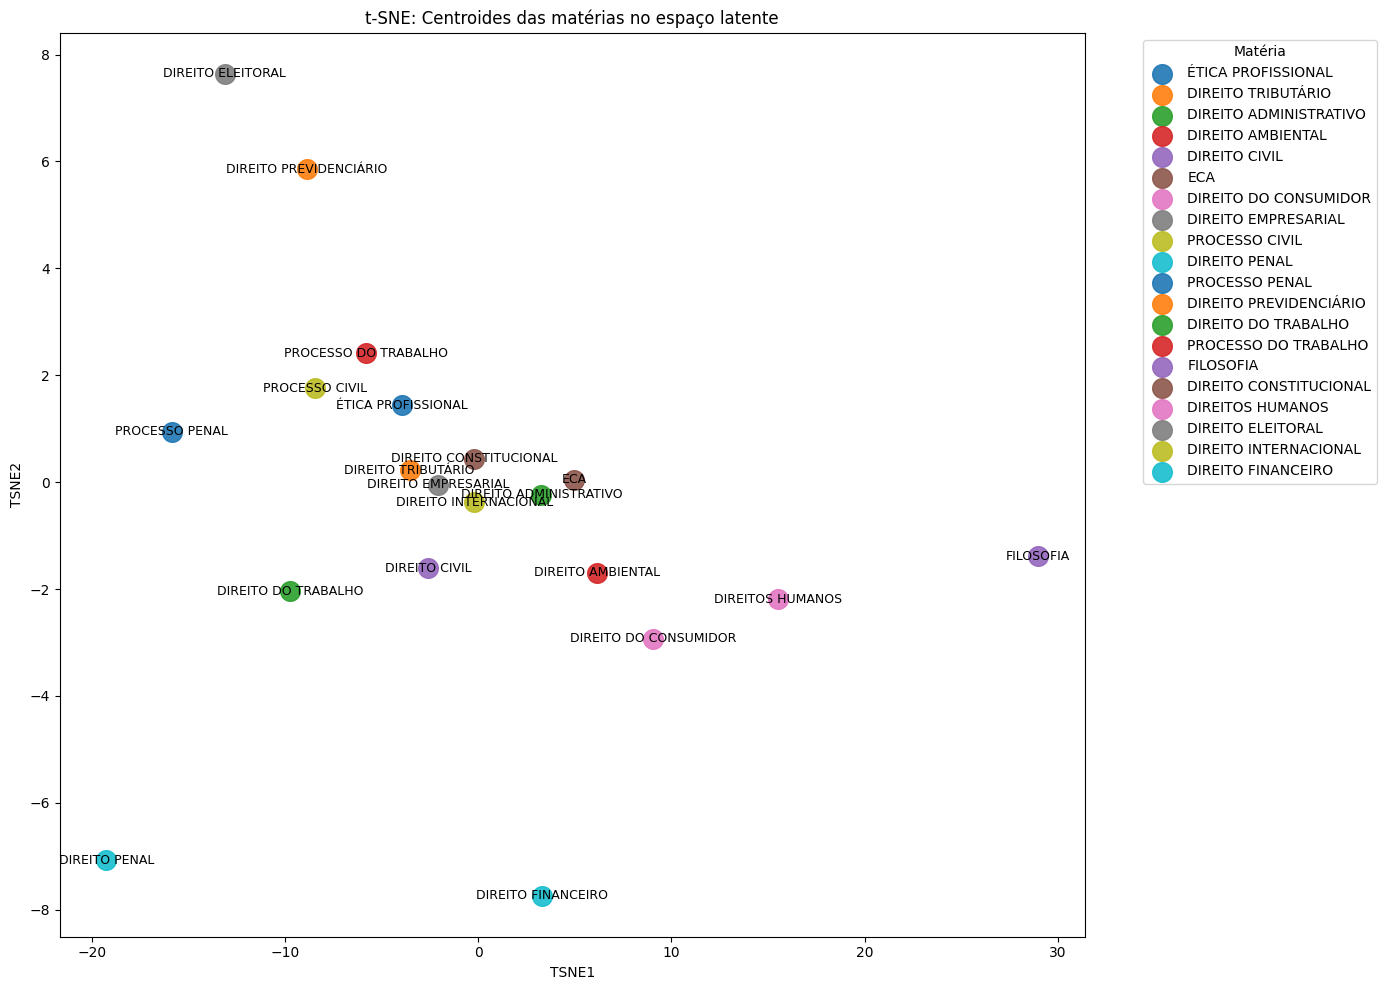

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

# Calcula e plota o centroide de cada matéria
for m in tsne_df["materia"].unique():
    mask = tsne_df["materia"] == m
    
    centroid_x = tsne_df.loc[mask, "TSNE1"].mean()
    centroid_y = tsne_df.loc[mask, "TSNE2"].mean()
    
    plt.scatter(
        centroid_x,
        centroid_y,
        s=200,          # tamanho maior para destacar o centroide
        alpha=0.9,
        label=m
    )
    
    # Rótulo textual do centroide
    plt.text(
        centroid_x,
        centroid_y,
        m,
        fontsize=9,
        ha="center",
        va="center"
    )

plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.title("t-SNE: Centroides das matérias no espaço latente")

plt.legend(
    title="Matéria",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# UMAP

In [73]:
import umap
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Seleciona features (exclui question_id)
features = question_wide_df.drop(columns=["question_id", "materia"])

# (recomendado) Padronização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# UMAP
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

# DataFrame com o embedding UMAP
umap_df = pd.DataFrame(
    X_umap,
    columns=["UMAP1", "UMAP2"],
    index=question_wide_df.index
)

# (opcional) adiciona metadados
umap_df["question_id"] = question_wide_df["question_id"]
umap_df["materia"] = question_wide_df["materia"]


C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\pedro\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


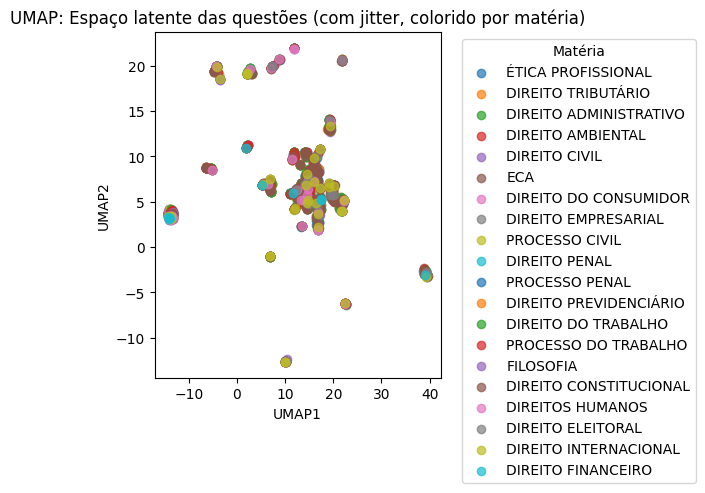

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# Intensidade do jitter (ajuste se necessário)
jitter_strength = 0.02

# Cria jitter
jitter_x = np.random.normal(0, jitter_strength, size=len(umap_df))
jitter_y = np.random.normal(0, jitter_strength, size=len(umap_df))

plt.figure()

for m in umap_df["materia"].unique():
    mask = umap_df["materia"] == m
    plt.scatter(
        umap_df.loc[mask, "UMAP1"] + jitter_x[mask],
        umap_df.loc[mask, "UMAP2"] + jitter_y[mask],
        label=m,
        alpha=0.7
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP: Espaço latente das questões (com jitter, colorido por matéria)")

plt.legend(
    title="Matéria",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


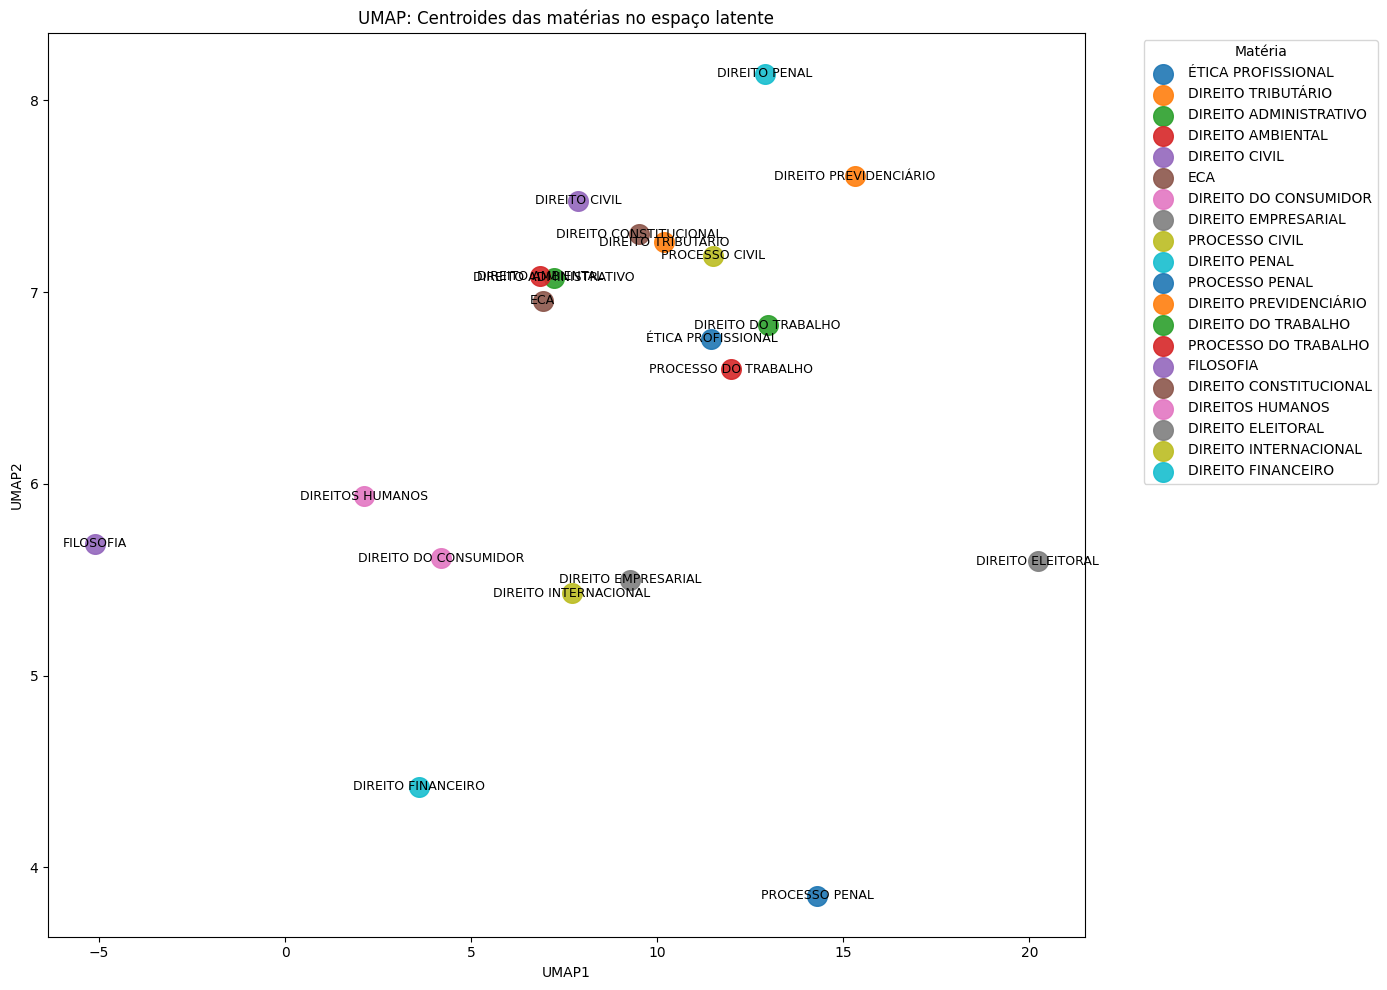

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

# Calcula e plota o centroide de cada matéria
for m in umap_df["materia"].unique():
    mask = umap_df["materia"] == m
    
    centroid_x = umap_df.loc[mask, "UMAP1"].mean()
    centroid_y = umap_df.loc[mask, "UMAP2"].mean()
    
    plt.scatter(
        centroid_x,
        centroid_y,
        s=200,          # tamanho maior para destacar o centroide
        alpha=0.9,
        label=m
    )
    
    # Opcional: rótulo textual do centroide
    plt.text(
        centroid_x,
        centroid_y,
        m,
        fontsize=9,
        ha="center",
        va="center"
    )

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP: Centroides das matérias no espaço latente")

plt.legend(
    title="Matéria",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()
